# ENIGMA-51 sequence classification pipeline

1. annotation 기반 EDA  
2. single-frame baseline (object / verb / pair)  
3. top-k pair 선택  
4. current pair / future pair 시퀀스 생성  
5. GRU / LSTM / BiLSTM + Adam / AdamW 비교  
6. current pair + next pair multitask transformer  
7. CSV / 모델 저장

## 0. 데이터 준비 


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# # Colab에서 처음 실행할 때만 사용
!mkdir -p /content/enigma_data/frames
!mkdir -p /content/enigma_data/annotations
!mkdir -p /content/enigma_data/features

!unzip "/content/drive/MyDrive/Human_projects/Projects/DL/enigma-51/zips/ENIGMA-51_frames.zip" -d /content/enigma_data/frames
!unzip "/content/drive/MyDrive/Human_projects/Projects/DL/enigma-51/zips/ENIGMA-51_annotations_master.zip" -d /content/enigma_data/annotations
!unzip "/content/drive/MyDrive/Human_projects/Projects/DL/enigma-51/zips/ENIGMA-51_DINOV2_exported_features_ViTg.zip" -d /content/enigma_data/features


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/drive/MyDrive/Human_projects/Projects/DL/enigma-51/zips/ENIGMA-51_frames.zip
replace /content/enigma_data/frames/enigma-data/frames/55_35718.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## 1. import / path 설정


In [ ]:
from pathlib import Path
from collections import Counter
import ast
import copy
import gc
import json
import math
import os
import random

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# -----------------------------
# paths
# -----------------------------
DATA_ROOT = Path("/content/enigma_data")
FRAMES_DIR = DATA_ROOT / "frames"
ANN_DIR = DATA_ROOT / "annotations"
FEATURE_DIR = DATA_ROOT / "features"

OUTPUT_ROOT = Path("/content/enigma_outputs")
CSV_DIR = OUTPUT_ROOT / "csv"
MODEL_DIR = OUTPUT_ROOT / "models"
FIG_DIR = OUTPUT_ROOT / "figures"

for d in [OUTPUT_ROOT, CSV_DIR, MODEL_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)


## 2. 공통 유틸 함수


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# 데이터 정제 및 변환
def _build_label_map(meta):
    label_map = {}

    if isinstance(meta, dict):
        for k, v in meta.items():
            idx = int(k)
            if isinstance(v, dict):
                name = v.get("name", str(v))
            else:
                name = str(v)
            label_map[idx] = name

    elif isinstance(meta, list):
        for i, v in enumerate(meta):
            if isinstance(v, dict):
                idx = int(v.get("id", i))
                name = v.get("name", str(v))
            else:
                idx = i
                name = str(v)
            label_map[idx] = name

    return label_map


def _clean_class_name(x):
    if isinstance(x, str) and x.startswith("{") and "class_name" in x:
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, dict) and "class_name" in parsed:
                return parsed["class_name"]
        except Exception:
            return x
    return x


def _load_feature(path):
    arr = np.load(path, allow_pickle=True)
    return arr.squeeze(0).astype(np.float32)  # (1, 1536) -> (1536,)

# 데이터 관리 및 저장
def _sort_video_df(g):
    if "timestamp_num" in g.columns and g["timestamp_num"].notna().any():
        return g.sort_values(["timestamp_num", "frame_key"]).reset_index(drop=True)
    return g.sort_values(["frame_key"]).reset_index(drop=True)


def save_csv(df, filename, encoding="utf-8-sig"):
    path = CSV_DIR / filename
    df.to_csv(path, index=False, encoding=encoding)
    print(f"[saved] {path}")
    return path

# 성능 평가
def compute_classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }


## 3. frame dataframe 생성 + EDA 함수


In [ ]:
def build_enigma_frame_df(
    ann_path=ANN_DIR / "ENIGMA-51_annotations_master.json"
):
    ann_path = Path(ann_path)

    with open(ann_path, "r") as f:
        data = json.load(f)

    frame_annotations = data["frame_annotations"]
    object_classes = data["object_classes"]
    interaction_types = data["interaction_types"]

    obj_map = _build_label_map(object_classes)
    verb_map = _build_label_map(interaction_types)

    all_detected_object_counter = Counter()
    interacting_object_counter = Counter()
    verb_counter = Counter()
    pair_counter = Counter()
    num_interactions_per_frame = Counter()

    rows = []

    for frame_key, ann in frame_annotations.items():
        objects = ann.get("objects", [])
        interactions = ann.get("interactions", [])

        obj_id_to_class_id = {obj["id"]: obj["class_id"] for obj in objects}

        for obj in objects:
            cls_id = obj["class_id"]
            obj_name = _clean_class_name(obj_map.get(cls_id, f"class_{cls_id}"))
            all_detected_object_counter[obj_name] += 1

        num_interactions_per_frame[len(interactions)] += 1

        current_frame_objects = []
        current_frame_verbs = []

        for inter in interactions:
            obj_id = inter["id_obj"]
            verb_id = inter["interaction_category"]

            cls_id = obj_id_to_class_id.get(obj_id, None)
            if cls_id is None:
                continue

            obj_name = _clean_class_name(obj_map.get(cls_id, f"class_{cls_id}"))
            verb_name = _clean_class_name(verb_map.get(verb_id, f"verb_{verb_id}"))

            interacting_object_counter[obj_name] += 1
            verb_counter[verb_name] += 1
            pair_counter[(verb_name, obj_name)] += 1

            current_frame_objects.append(obj_name)
            current_frame_verbs.append(verb_name)

        rows.append({
            "frame_key": frame_key,
            "video_id": ann.get("video_id"),
            "timestamp": ann.get("timestamp"),
            "num_objects_detected": len(objects),
            "num_interactions": len(interactions),
            "interacting_objects": current_frame_objects,
            "verbs": current_frame_verbs,
        })

    df_frames = pd.DataFrame(rows)

    df_all_objects = pd.DataFrame(
        all_detected_object_counter.most_common(),
        columns=["object", "count"]
    )

    df_interacting_objects = pd.DataFrame(
        interacting_object_counter.most_common(),
        columns=["object", "count"]
    )
    if len(df_interacting_objects) > 0:
        df_interacting_objects["ratio"] = (
            df_interacting_objects["count"] / df_interacting_objects["count"].sum()
        )

    df_verbs = pd.DataFrame(
        verb_counter.most_common(),
        columns=["verb", "count"]
    )
    if len(df_verbs) > 0:
        df_verbs["ratio"] = df_verbs["count"] / df_verbs["count"].sum()

    df_pairs = pd.DataFrame(
        [(verb, obj, cnt) for (verb, obj), cnt in pair_counter.most_common()],
        columns=["verb", "object", "count"]
    )
    if len(df_pairs) > 0:
        df_pairs["pair"] = df_pairs["verb"] + "__" + df_pairs["object"]
        df_pairs["ratio"] = df_pairs["count"] / df_pairs["count"].sum()

    df_interactions_per_frame = pd.DataFrame(
        sorted(num_interactions_per_frame.items()),
        columns=["num_interactions", "frame_count"]
    )

    return {
        "df_frames": df_frames,
        "df_all_objects": df_all_objects,
        "df_interacting_objects": df_interacting_objects,
        "df_verbs": df_verbs,
        "df_pairs": df_pairs,
        "df_interactions_per_frame": df_interactions_per_frame,
    }


def make_single_interaction_df(df_frames, num_interactions_only=1):
    if num_interactions_only is None:
        df = df_frames[df_frames["num_interactions"] > 0].copy()
    else:
        df = df_frames[df_frames["num_interactions"] == num_interactions_only].copy()

    df = df.copy()

    df["target_object"] = df["interacting_objects"].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
    )
    df["target_verb"] = df["verbs"].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
    )

    df = df.dropna(subset=["target_object", "target_verb"]).copy()

    df["target_pair"] = df.apply(
        lambda row: f"{row['target_verb']}__{row['target_object']}",
        axis=1
    )

    return df


def get_distribution(df_frames, target_mode="object", num_interactions_only=1, top_k=20):
    df = make_single_interaction_df(df_frames, num_interactions_only=num_interactions_only)

    if target_mode == "object":
        target_col = "target_object"
    elif target_mode == "verb":
        target_col = "target_verb"
    elif target_mode == "pair":
        target_col = "target_pair"
    else:
        raise ValueError("target_mode must be 'object', 'verb', or 'pair'")

    dist = df[target_col].value_counts().reset_index()
    dist.columns = [target_col, "count"]
    dist["ratio"] = dist["count"] / dist["count"].sum()

    return df, dist.head(top_k)


def run_eda_and_save():
    data_dict = build_enigma_frame_df()
    df_frames = data_dict["df_frames"]

    save_csv(df_frames, "eda_frames.csv")
    save_csv(data_dict["df_all_objects"], "eda_all_objects.csv")
    save_csv(data_dict["df_interacting_objects"], "eda_interacting_objects.csv")
    save_csv(data_dict["df_verbs"], "eda_verbs.csv")
    save_csv(data_dict["df_pairs"], "eda_pairs.csv")
    save_csv(data_dict["df_interactions_per_frame"], "eda_num_interactions_per_frame.csv")

    df_single = make_single_interaction_df(df_frames, num_interactions_only=1)
    save_csv(df_single, "single_interaction_frames.csv")

    _, dist_obj = get_distribution(df_frames, "object", 1, top_k=30)
    _, dist_verb = get_distribution(df_frames, "verb", 1, top_k=30)
    _, dist_pair = get_distribution(df_frames, "pair", 1, top_k=50)

    save_csv(dist_obj, "dist_top_objects_single_interaction.csv")
    save_csv(dist_verb, "dist_top_verbs_single_interaction.csv")
    save_csv(dist_pair, "dist_top_pairs_single_interaction.csv")

    return data_dict, df_frames, df_single


## 4. single-frame baseline 함수


In [ ]:
def run_baseline(
    df_frames,
    feature_root=FEATURE_DIR,
    target_mode="object",
    num_interactions_only=1,
    top_k=6,
    candidate_classes=None,
    test_size=0.2,
    val_size_within_temp=0.5,
    random_state=42,
    class_weight="balanced",
    max_iter=2000,
    verbose=True
):
    df_single = make_single_interaction_df(df_frames, num_interactions_only=num_interactions_only)

    if target_mode == "object":
        target_col = "target_object"
    elif target_mode == "verb":
        target_col = "target_verb"
    elif target_mode == "pair":
        target_col = "target_pair"
    else:
        raise ValueError("target_mode must be 'object', 'verb', or 'pair'")

    if candidate_classes is None:
        selected_classes = df_single[target_col].value_counts().head(top_k).index.tolist()
    else:
        selected_classes = candidate_classes

    df_task = df_single[df_single[target_col].isin(selected_classes)].copy()

    feature_root = Path(feature_root)
    npy_files = list(feature_root.rglob("*.npy"))
    feature_path_map = {p.stem: str(p) for p in npy_files}

    df_task["feature_path"] = df_task["frame_key"].map(feature_path_map)
    df_task = df_task[df_task["feature_path"].notna()].copy()

    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, temp_idx = next(gss1.split(df_task, groups=df_task["video_id"]))

    df_train = df_task.iloc[train_idx].copy()
    df_temp = df_task.iloc[temp_idx].copy()

    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_size_within_temp, random_state=random_state)
    val_idx, test_idx = next(gss2.split(df_temp, groups=df_temp["video_id"]))

    df_val = df_temp.iloc[val_idx].copy()
    df_test = df_temp.iloc[test_idx].copy()

    majority_class = df_train[target_col].value_counts().idxmax()
    y_test_majority_true = df_test[target_col].values
    y_test_majority_pred = np.array([majority_class] * len(df_test))

    maj_metrics = compute_classification_metrics(y_test_majority_true, y_test_majority_pred)

    X_train = np.stack(df_train["feature_path"].apply(_load_feature).values)
    X_val = np.stack(df_val["feature_path"].apply(_load_feature).values)
    X_test = np.stack(df_test["feature_path"].apply(_load_feature).values)

    le = LabelEncoder()
    y_train = le.fit_transform(df_train[target_col])
    y_val = le.transform(df_val[target_col])
    y_test = le.transform(df_test[target_col])

    clf = LogisticRegression(
        max_iter=max_iter,
        class_weight=class_weight,
        random_state=random_state
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    log_metrics = compute_classification_metrics(y_test, y_pred)

    report = classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        output_dict=True,
        zero_division=0
    )
    cm = confusion_matrix(y_test, y_pred)

    if verbose:
        print("=" * 90)
        print(f"[baseline] target_mode={target_mode}")
        print("selected_classes:", selected_classes)
        print(f"single-label frames: {len(df_single)}")
        print(f"task samples: {len(df_task)}")
        print()
        print("[split]")
        print(f"train={len(df_train)} ({df_train['video_id'].nunique()} videos)")
        print(f"val  ={len(df_val)} ({df_val['video_id'].nunique()} videos)")
        print(f"test ={len(df_test)} ({df_test['video_id'].nunique()} videos)")
        print()
        print("[majority]")
        print(maj_metrics)
        print()
        print("[logreg]")
        print(log_metrics)
        print("=" * 90)

    return {
        "df_single": df_single,
        "df_task": df_task,
        "df_train": df_train,
        "df_val": df_val,
        "df_test": df_test,
        "selected_classes": selected_classes,
        "target_col": target_col,
        "label_encoder": le,
        "model": clf,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "y_pred": y_pred,
        "majority_class": majority_class,
        "majority_metrics": maj_metrics,
        "logreg_metrics": log_metrics,
        "classification_report": report,
        "confusion_matrix": cm,
    }


def run_baseline_suite(df_frames, top_k=6):
    rows = []
    result_dict = {}

    for mode in ["object", "verb", "pair"]:
        result = run_baseline(
            df_frames=df_frames,
            feature_root=FEATURE_DIR,
            target_mode=mode,
            num_interactions_only=1,
            top_k=top_k,
            random_state=42,
            verbose=True
        )
        result_dict[mode] = result

        rows.append({
            "mode": mode,
            "selected_classes": " | ".join(result["selected_classes"]),
            "accuracy": result["logreg_metrics"]["accuracy"],
            "macro_f1": result["logreg_metrics"]["macro_f1"],
            "balanced_accuracy": result["logreg_metrics"]["balanced_accuracy"],
        })

        cm_df = pd.DataFrame(
            result["confusion_matrix"],
            index=result["label_encoder"].classes_,
            columns=result["label_encoder"].classes_,
        )
        save_csv(cm_df.reset_index(), f"baseline_cm_{mode}_top{top_k}.csv")
        save_csv(pd.DataFrame(result["classification_report"]).T.reset_index(), f"baseline_report_{mode}_top{top_k}.csv")

    summary_df = pd.DataFrame(rows).sort_values(
        ["macro_f1", "balanced_accuracy", "accuracy"],
        ascending=False
    ).reset_index(drop=True)

    save_csv(summary_df, f"baseline_summary_top{top_k}.csv")
    return result_dict, summary_df


def compare_topk(
    df_frames,
    target_mode="pair",
    topk_list=(4, 6, 8),
    feature_root=FEATURE_DIR,
    num_interactions_only=1,
    random_state=42,
    verbose=False
):
    all_results = {}
    rows = []

    for k in topk_list:
        res = run_baseline(
            df_frames=df_frames,
            feature_root=feature_root,
            target_mode=target_mode,
            num_interactions_only=num_interactions_only,
            top_k=k,
            random_state=random_state,
            verbose=verbose
        )

        all_results[k] = res
        rows.append({
            "target_mode": target_mode,
            "top_k": k,
            "num_selected_classes": len(res["selected_classes"]),
            "selected_classes": " | ".join(res["selected_classes"]),
            "accuracy": res["logreg_metrics"]["accuracy"],
            "macro_f1": res["logreg_metrics"]["macro_f1"],
            "balanced_accuracy": res["logreg_metrics"]["balanced_accuracy"],
        })

    compare_df = pd.DataFrame(rows).sort_values(
        ["macro_f1", "balanced_accuracy", "accuracy"],
        ascending=False
    ).reset_index(drop=True)

    return all_results, compare_df


## 4-1. single-frame MLP baseline (optional)

기존 `LogisticRegression` baseline은 그대로 두고,  
동일한 single-frame feature 입력에 대해 `MLP` baseline을 추가할 때 사용하는 함수입니다.

권장 사용 방식:
- `Cell 24`의 baseline summary는 그대로 유지
- `Cell 28`에서 만든 `df_train_pair / df_val_pair / df_test_pair` split을 그대로 사용
- 같은 split에서 `Logistic Regression vs MLP`를 비교



In [ ]:
class SingleFrameDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class SingleFrameMLP(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dims=(512, 256), dropout=0.3):
        super().__init__()

        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def prepare_single_frame_encoded_dataset(
    df_train,
    df_val,
    df_test,
    target_col="target_pair",
):
    X_train = np.stack(df_train["feature_path"].apply(_load_feature).values)
    X_val = np.stack(df_val["feature_path"].apply(_load_feature).values)
    X_test = np.stack(df_test["feature_path"].apply(_load_feature).values)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    le = LabelEncoder()
    y_train = le.fit_transform(df_train[target_col])
    y_val = le.transform(df_val[target_col])
    y_test = le.transform(df_test[target_col])

    return {
        "X_train": X_train.astype(np.float32),
        "X_val": X_val.astype(np.float32),
        "X_test": X_test.astype(np.float32),
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "label_encoder": le,
        "scaler": scaler,
    }


def evaluate_single_frame_torch_model(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * len(y_batch)
            preds = torch.argmax(logits, dim=1)

            y_true_all.extend(y_batch.cpu().numpy().tolist())
            y_pred_all.extend(preds.cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_classification_metrics(y_true_all, y_pred_all)
    metrics["loss"] = avg_loss
    return metrics


def run_logreg_on_single_frame_dataset(
    single_data,
    max_iter=2000,
    class_weight="balanced",
    random_state=42
):
    clf = LogisticRegression(
        max_iter=max_iter,
        class_weight=class_weight,
        random_state=random_state
    )
    clf.fit(single_data["X_train"], single_data["y_train"])

    y_pred = clf.predict(single_data["X_test"])
    metrics = compute_classification_metrics(single_data["y_test"], y_pred)

    report = classification_report(
        single_data["y_test"],
        y_pred,
        target_names=single_data["label_encoder"].classes_,
        output_dict=True,
        zero_division=0
    )
    cm = confusion_matrix(single_data["y_test"], y_pred)

    return {
        "model": clf,
        "metrics": metrics,
        "y_pred": y_pred,
        "classification_report": report,
        "confusion_matrix": cm,
    }


def train_single_frame_mlp(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    hidden_dims=(512, 256),
    dropout=0.3,
    lr=1e-3,
    batch_size=64,
    max_epochs=30,
    patience=7,
    weight_decay=1e-4,
    random_state=42,
    model_save_name="single_frame_mlp.pt"
):
    set_seed(random_state)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_ds = SingleFrameDataset(X_train, y_train)
    val_ds = SingleFrameDataset(X_val, y_val)
    test_ds = SingleFrameDataset(X_test, y_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    model = SingleFrameMLP(
        input_dim=X_train.shape[1],
        num_classes=len(np.unique(y_train)),
        hidden_dims=hidden_dims,
        dropout=dropout
    ).to(device)

    # 불균형 처리
    class_weights = build_class_weights(y_train, num_classes=len(np.unique(y_train))).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_state = None
    best_val_macro_f1 = -1.0
    best_epoch = -1
    wait = 0
    history = []

    for epoch in range(max_epochs):
        model.train()
        total_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss += loss.item() * len(y_batch)

        train_loss = total_train_loss / len(train_loader.dataset)
        val_metrics = evaluate_single_frame_torch_model(model, val_loader, criterion, device)
        scheduler.step(val_metrics["macro_f1"])
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"[MLP] epoch={epoch+1:02d} "
            f"lr={current_lr:.6f} "
            f"train_loss={train_loss:.4f} "
            f"val_loss={val_metrics['loss']:.4f} "
            f"val_acc={val_metrics['accuracy']:.4f} "
            f"val_f1={val_metrics['macro_f1']:.4f} "
            f"val_bal_acc={val_metrics['balanced_accuracy']:.4f}"
        )

        history.append({
            "epoch": epoch + 1,
            "lr": current_lr,
            "train_loss": train_loss,
            **{f"val_{k}": v for k, v in val_metrics.items()}
        })

        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("early stopping")
                break

    model.load_state_dict(best_state)

    val_metrics = evaluate_single_frame_torch_model(model, val_loader, criterion, device)
    test_metrics = evaluate_single_frame_torch_model(model, test_loader, criterion, device)

    y_true_all = []
    y_pred_all = []
    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            preds = torch.argmax(logits, dim=1)

            y_true_all.extend(y_batch.numpy().tolist())
            y_pred_all.extend(preds.cpu().numpy().tolist())

    history_df = pd.DataFrame(history)
    if model_save_name is not None:
        torch.save(model.state_dict(), MODEL_DIR / model_save_name)
        save_csv(history_df, model_save_name.replace(".pt", "_history.csv"))

    report = classification_report(
        y_true_all,
        y_pred_all,
        output_dict=True,
        zero_division=0
    )
    cm = confusion_matrix(y_true_all, y_pred_all)

    return {
        "model": model,
        "best_epoch": best_epoch,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "history_df": history_df,
        "y_test_true": y_true_all,
        "y_test_pred": y_pred_all,
        "classification_report": report,
        "confusion_matrix": cm,
    }


## 5. pair task dataframe / split 함수 + 2-stage 준비

In [ ]:
def prepare_pair_task_df(
    df_frames,
    selected_pairs,
    feature_root=FEATURE_DIR,
    num_interactions_only=1
):
    df_single = make_single_interaction_df(df_frames, num_interactions_only=num_interactions_only).copy()
    df_task = df_single[df_single["target_pair"].isin(selected_pairs)].copy()

    feature_root = Path(feature_root)
    npy_files = list(feature_root.rglob("*.npy"))
    feature_path_map = {p.stem: str(p) for p in npy_files}

    df_task["feature_path"] = df_task["frame_key"].map(feature_path_map)
    df_task = df_task[df_task["feature_path"].notna()].copy()

    if "timestamp" in df_task.columns:
        df_task["timestamp_num"] = pd.to_numeric(df_task["timestamp"], errors="coerce")
    else:
        df_task["timestamp_num"] = np.nan

    return df_task


def split_by_video_id(
    df_task,
    test_size=0.2,
    val_size_within_temp=0.5,
    random_state=42
):
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, temp_idx = next(gss1.split(df_task, groups=df_task["video_id"]))

    df_train = df_task.iloc[train_idx].copy()
    df_temp = df_task.iloc[temp_idx].copy()

    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_size_within_temp, random_state=random_state)
    val_idx, test_idx = next(gss2.split(df_temp, groups=df_temp["video_id"]))

    df_val = df_temp.iloc[val_idx].copy()
    df_test = df_temp.iloc[test_idx].copy()

    return df_train, df_val, df_test

# train split 기준으로 top-k 비교하는 함수
def prepare_all_pair_task_df(
    df_frames,
    feature_root=FEATURE_DIR,
    num_interactions_only=1
):
    df_single = make_single_interaction_df(
        df_frames,
        num_interactions_only=num_interactions_only
    ).copy()

    df_task = df_single.copy()

    feature_root = Path(feature_root)
    npy_files = list(feature_root.rglob("*.npy"))
    feature_path_map = {p.stem: str(p) for p in npy_files}

    df_task["feature_path"] = df_task["frame_key"].map(feature_path_map)
    df_task = df_task[df_task["feature_path"].notna()].copy()

    if "timestamp" in df_task.columns:
        df_task["timestamp_num"] = pd.to_numeric(df_task["timestamp"], errors="coerce")
    else:
        df_task["timestamp_num"] = np.nan

    return df_task


def evaluate_logreg_on_fixed_split(
    df_train,
    df_val,
    df_test,
    target_col="target_pair",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
):
    if len(df_train) == 0 or len(df_val) == 0 or len(df_test) == 0:
        raise ValueError("One of train/val/test is empty after filtering.")

    X_train = np.stack(df_train["feature_path"].apply(_load_feature).values)
    X_val = np.stack(df_val["feature_path"].apply(_load_feature).values)
    X_test = np.stack(df_test["feature_path"].apply(_load_feature).values)

    le = LabelEncoder()
    y_train = le.fit_transform(df_train[target_col])
    y_val = le.transform(df_val[target_col])
    y_test = le.transform(df_test[target_col])

    clf = LogisticRegression(
        max_iter=max_iter,
        class_weight=class_weight,
        random_state=random_state
    )
    clf.fit(X_train, y_train)

    y_val_pred = clf.predict(X_val)
    y_test_pred = clf.predict(X_test)

    return {
        "model": clf,
        "label_encoder": le,
        "val_metrics": compute_classification_metrics(y_val, y_val_pred),
        "test_metrics": compute_classification_metrics(y_test, y_test_pred),
    }


def compare_pair_topk_on_train_split(
    df_train_all,
    df_val_all,
    df_test_all,
    topk_list=(4, 6, 8),
    target_col="target_pair",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
):
    rows = []
    all_results = {}

    train_full_counts = df_train_all[target_col].value_counts()

    for k in topk_list:
        selected_classes = train_full_counts.head(k).index.tolist()

        df_train_k = df_train_all[df_train_all[target_col].isin(selected_classes)].copy()
        df_val_k = df_val_all[df_val_all[target_col].isin(selected_classes)].copy()
        df_test_k = df_test_all[df_test_all[target_col].isin(selected_classes)].copy()

        res = evaluate_logreg_on_fixed_split(
            df_train=df_train_k,
            df_val=df_val_k,
            df_test=df_test_k,
            target_col=target_col,
            class_weight=class_weight,
            max_iter=max_iter,
            random_state=random_state
        )

        train_counts = df_train_k[target_col].value_counts().reindex(selected_classes, fill_value=0)
        val_counts = df_val_k[target_col].value_counts().reindex(selected_classes, fill_value=0)
        test_counts = df_test_k[target_col].value_counts().reindex(selected_classes, fill_value=0)

        rows.append({
            "top_k": k,
            "selected_classes": " | ".join(selected_classes),
            "train_samples": len(df_train_k),
            "val_samples": len(df_val_k),
            "test_samples": len(df_test_k),
            "min_train_count": int(train_counts.min()),
            "min_val_count": int(val_counts.min()),
            "min_test_count": int(test_counts.min()),
            "train_max_min_ratio": round(train_counts.max() / max(train_counts.min(), 1), 2),
            "val_macro_f1": res["val_metrics"]["macro_f1"],
            "val_balanced_accuracy": res["val_metrics"]["balanced_accuracy"],
            "test_macro_f1": res["test_metrics"]["macro_f1"],
            "test_balanced_accuracy": res["test_metrics"]["balanced_accuracy"],
        })

        all_results[k] = {
            "selected_classes": selected_classes,
            "df_train": df_train_k,
            "df_val": df_val_k,
            "df_test": df_test_k,
            **res
        }

    compare_df = pd.DataFrame(rows).sort_values(
        ["val_macro_f1", "val_balanced_accuracy", "test_macro_f1"],
        ascending=False
    ).reset_index(drop=True)

    return all_results, compare_df

def prepare_all_pair_task_df(
    df_frames,
    feature_root=FEATURE_DIR,
    num_interactions_only=1
):
    df_single = make_single_interaction_df(
        df_frames,
        num_interactions_only=num_interactions_only
    ).copy()

    df_task = df_single.copy()

    feature_root = Path(feature_root)
    npy_files = list(feature_root.rglob("*.npy"))
    feature_path_map = {p.stem: str(p) for p in npy_files}

    df_task["feature_path"] = df_task["frame_key"].map(feature_path_map)
    df_task = df_task[df_task["feature_path"].notna()].copy()

    if "timestamp" in df_task.columns:
        df_task["timestamp_num"] = pd.to_numeric(df_task["timestamp"], errors="coerce")
    else:
        df_task["timestamp_num"] = np.nan

    return df_task


def evaluate_logreg_on_fixed_split(
    df_train,
    df_val,
    df_test,
    target_col="target_pair",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
):
    if len(df_train) == 0 or len(df_val) == 0 or len(df_test) == 0:
        raise ValueError("One of train/val/test is empty after filtering.")

    X_train = np.stack(df_train["feature_path"].apply(_load_feature).values)
    X_val = np.stack(df_val["feature_path"].apply(_load_feature).values)
    X_test = np.stack(df_test["feature_path"].apply(_load_feature).values)

    le = LabelEncoder()
    y_train = le.fit_transform(df_train[target_col])
    y_val = le.transform(df_val[target_col])
    y_test = le.transform(df_test[target_col])

    clf = LogisticRegression(
        max_iter=max_iter,
        class_weight=class_weight,
        random_state=random_state
    )
    clf.fit(X_train, y_train)

    y_val_pred = clf.predict(X_val)
    y_test_pred = clf.predict(X_test)

    return {
        "model": clf,
        "label_encoder": le,
        "val_metrics": compute_classification_metrics(y_val, y_val_pred),
        "test_metrics": compute_classification_metrics(y_test, y_test_pred),
    }


def compare_pair_topk_on_train_split(
    df_train_all,
    df_val_all,
    df_test_all,
    topk_list=(4, 6, 8),
    target_col="target_pair",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
):
    rows = []
    all_results = {}

    train_full_counts = df_train_all[target_col].value_counts()

    for k in topk_list:
        selected_classes = train_full_counts.head(k).index.tolist()

        df_train_k = df_train_all[df_train_all[target_col].isin(selected_classes)].copy()
        df_val_k = df_val_all[df_val_all[target_col].isin(selected_classes)].copy()
        df_test_k = df_test_all[df_test_all[target_col].isin(selected_classes)].copy()

        res = evaluate_logreg_on_fixed_split(
            df_train=df_train_k,
            df_val=df_val_k,
            df_test=df_test_k,
            target_col=target_col,
            class_weight=class_weight,
            max_iter=max_iter,
            random_state=random_state
        )

        train_counts = df_train_k[target_col].value_counts().reindex(selected_classes, fill_value=0)
        val_counts = df_val_k[target_col].value_counts().reindex(selected_classes, fill_value=0)
        test_counts = df_test_k[target_col].value_counts().reindex(selected_classes, fill_value=0)

        rows.append({
            "top_k": k,
            "selected_classes": " | ".join(selected_classes),
            "train_samples": len(df_train_k),
            "val_samples": len(df_val_k),
            "test_samples": len(df_test_k),
            "min_train_count": int(train_counts.min()),
            "min_val_count": int(val_counts.min()),
            "min_test_count": int(test_counts.min()),
            "train_max_min_ratio": round(train_counts.max() / max(train_counts.min(), 1), 2),
            "val_macro_f1": res["val_metrics"]["macro_f1"],
            "val_balanced_accuracy": res["val_metrics"]["balanced_accuracy"],
            "test_macro_f1": res["test_metrics"]["macro_f1"],
            "test_balanced_accuracy": res["test_metrics"]["balanced_accuracy"],
        })

        all_results[k] = {
            "selected_classes": selected_classes,
            "df_train": df_train_k,
            "df_val": df_val_k,
            "df_test": df_test_k,
            **res
        }

    compare_df = pd.DataFrame(rows).sort_values(
        ["val_macro_f1", "val_balanced_accuracy", "test_macro_f1"],
        ascending=False
    ).reset_index(drop=True)

    return all_results, compare_df


## 5-1. 2-stage용 interaction task 함수

In [ ]:
def make_interaction_presence_df(df_frames, allowed_num_interactions=(0, 1)):
    df = df_frames[df_frames["num_interactions"].isin(allowed_num_interactions)].copy()
    df["interaction_target"] = (df["num_interactions"] > 0).astype(int)
    # 0 = no_interaction
    # 1 = interaction_present
    return df


def attach_feature_paths(df_task, feature_root=FEATURE_DIR):
    feature_root = Path(feature_root)
    npy_files = list(feature_root.rglob("*.npy"))
    feature_path_map = {p.stem: str(p) for p in npy_files}

    df_task = df_task.copy()
    df_task["feature_path"] = df_task["frame_key"].map(feature_path_map)
    df_task = df_task[df_task["feature_path"].notna()].copy()

    if "timestamp" in df_task.columns:
        df_task["timestamp_num"] = pd.to_numeric(df_task["timestamp"], errors="coerce")
    else:
        df_task["timestamp_num"] = np.nan

    return df_task


def run_interaction_baseline(
    df_frames,
    feature_root=FEATURE_DIR,
    allowed_num_interactions=(0, 1),
    test_size=0.2,
    val_size_within_temp=0.5,
    random_state=42,
    class_weight="balanced",
    max_iter=2000,
    verbose=True
):
    df_task = make_interaction_presence_df(
        df_frames,
        allowed_num_interactions=allowed_num_interactions
    )
    df_task = attach_feature_paths(df_task, feature_root=feature_root)

    df_train, df_val, df_test = split_by_video_id(
        df_task,
        test_size=test_size,
        val_size_within_temp=val_size_within_temp,
        random_state=random_state
    )

    X_train = np.stack(df_train["feature_path"].apply(_load_feature).values)
    X_val = np.stack(df_val["feature_path"].apply(_load_feature).values)
    X_test = np.stack(df_test["feature_path"].apply(_load_feature).values)

    le = LabelEncoder()
    y_train = le.fit_transform(df_train["interaction_target"])
    y_val = le.transform(df_val["interaction_target"])
    y_test = le.transform(df_test["interaction_target"])

    majority_class = pd.Series(y_train).value_counts().idxmax()
    y_test_majority_pred = np.array([majority_class] * len(y_test))
    maj_metrics = compute_classification_metrics(y_test, y_test_majority_pred)

    clf = LogisticRegression(
        max_iter=max_iter,
        class_weight=class_weight,
        random_state=random_state
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    log_metrics = compute_classification_metrics(y_test, y_pred)

    report = classification_report(
        y_test,
        y_pred,
        target_names=[str(x) for x in le.classes_],
        output_dict=True,
        zero_division=0
    )
    cm = confusion_matrix(y_test, y_pred)

    if verbose:
        print("=" * 90)
        print("[interaction baseline]")
        print(f"task samples: {len(df_task)}")
        print()
        print("[split]")
        print(f"train={len(df_train)} ({df_train['video_id'].nunique()} videos)")
        print(f"val  ={len(df_val)} ({df_val['video_id'].nunique()} videos)")
        print(f"test ={len(df_test)} ({df_test['video_id'].nunique()} videos)")
        print()
        print("[majority]")
        print(maj_metrics)
        print()
        print("[logreg]")
        print(log_metrics)
        print("=" * 90)

    return {
        "df_task": df_task,
        "df_train": df_train,
        "df_val": df_val,
        "df_test": df_test,
        "label_encoder": le,
        "model": clf,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "y_pred": y_pred,
        "majority_metrics": maj_metrics,
        "logreg_metrics": log_metrics,
        "classification_report": report,
        "confusion_matrix": cm,
    }


## 6. 시퀀스 생성 함수


In [ ]:
def make_sequence_arrays(
    df_split,
    seq_len=8,
    label_col="target_pair",
    stride=1
):
    X_list = []
    y_list = []
    meta_rows = []

    for video_id, g in df_split.groupby("video_id"):
        g = _sort_video_df(g)

        feature_paths = g["feature_path"].tolist()
        labels = g[label_col].tolist()
        frame_keys = g["frame_key"].tolist()

        if len(g) < seq_len:
            continue

        feat_list = [_load_feature(p) for p in feature_paths]

        for end_idx in range(seq_len - 1, len(g), stride):
            start_idx = end_idx - seq_len + 1

            seq_feats = np.stack(feat_list[start_idx:end_idx + 1], axis=0)
            seq_label = labels[end_idx]

            X_list.append(seq_feats)
            y_list.append(seq_label)
            meta_rows.append({
                "video_id": video_id,
                "start_frame_key": frame_keys[start_idx],
                "end_frame_key": frame_keys[end_idx],
            })

    X = np.stack(X_list) if len(X_list) > 0 else np.empty((0, seq_len, 1536), dtype=np.float32)
    y = np.array(y_list)
    meta_df = pd.DataFrame(meta_rows)

    return X, y, meta_df


def make_future_sequence_arrays(
    df_split,
    seq_len=4,
    future_offset=1,
    label_col="target_pair",
    stride=1
):
    X_list = []
    y_list = []
    meta_rows = []

    for video_id, g in df_split.groupby("video_id"):
        g = _sort_video_df(g)

        feature_paths = g["feature_path"].tolist()
        labels = g[label_col].tolist()
        frame_keys = g["frame_key"].tolist()

        if len(g) < seq_len + future_offset:
            continue

        feat_list = [_load_feature(p) for p in feature_paths]
        max_end_idx = len(g) - 1 - future_offset

        for end_idx in range(seq_len - 1, max_end_idx + 1, stride):
            start_idx = end_idx - seq_len + 1
            target_idx = end_idx + future_offset

            seq_feats = np.stack(feat_list[start_idx:end_idx + 1], axis=0)
            future_label = labels[target_idx]

            X_list.append(seq_feats)
            y_list.append(future_label)

            meta_rows.append({
                "video_id": video_id,
                "start_frame_key": frame_keys[start_idx],
                "end_frame_key": frame_keys[end_idx],
                "target_frame_key": frame_keys[target_idx],
                "future_offset": future_offset,
            })

    X = np.stack(X_list) if len(X_list) > 0 else np.empty((0, seq_len, 1536), dtype=np.float32)
    y = np.array(y_list)
    meta_df = pd.DataFrame(meta_rows)

    return X, y, meta_df


def make_current_next_sequence_arrays(
    df_split,
    seq_len=4,
    future_offset=1,
    label_col="target_pair",
    stride=1
):
    X_list = []
    y_current_list = []
    y_future_list = []
    meta_rows = []

    for video_id, g in df_split.groupby("video_id"):
        g = _sort_video_df(g)

        feature_paths = g["feature_path"].tolist()
        labels = g[label_col].tolist()
        frame_keys = g["frame_key"].tolist()

        if len(g) < seq_len + future_offset:
            continue

        feat_list = [_load_feature(p) for p in feature_paths]
        max_end_idx = len(g) - 1 - future_offset

        for end_idx in range(seq_len - 1, max_end_idx + 1, stride):
            start_idx = end_idx - seq_len + 1
            target_idx = end_idx + future_offset

            seq_feats = np.stack(feat_list[start_idx:end_idx + 1], axis=0)

            X_list.append(seq_feats)
            y_current_list.append(labels[end_idx])
            y_future_list.append(labels[target_idx])

            meta_rows.append({
                "video_id": video_id,
                "start_frame_key": frame_keys[start_idx],
                "end_frame_key": frame_keys[end_idx],
                "target_frame_key": frame_keys[target_idx],
                "future_offset": future_offset,
            })

    X = np.stack(X_list) if len(X_list) > 0 else np.empty((0, seq_len, 1536), dtype=np.float32)
    y_current = np.array(y_current_list)
    y_future = np.array(y_future_list)
    meta_df = pd.DataFrame(meta_rows)

    return X, y_current, y_future, meta_df


def fit_sequence_scaler(X_train):
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, X_train.shape[-1]))
    return scaler


def transform_sequence_array(X, scaler):
    orig_shape = X.shape
    X_scaled = scaler.transform(X.reshape(-1, orig_shape[-1])).reshape(orig_shape)
    return X_scaled.astype(np.float32)

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class MultiTaskSequenceDataset(Dataset):
    def __init__(self, X, y_current, y_future):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_current = torch.tensor(y_current, dtype=torch.long)
        self.y_future = torch.tensor(y_future, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_current[idx], self.y_future[idx]


## 7. RNN 계열 모델 (`GRU / LSTM / BiLSTM`)


In [ ]:
class SequenceClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        num_classes,
        model_type="GRU",
        hidden_size=128,
        num_layers=1,
        dropout=0.2,
        bidirectional=False
    ):
        super().__init__()

        self.model_type = model_type.upper()
        self.bidirectional = bidirectional

        rnn_cls = nn.GRU if self.model_type == "GRU" else nn.LSTM
        rnn_dropout = dropout if num_layers > 1 else 0.0

        self.rnn = rnn_cls(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=rnn_dropout,
            batch_first=True,
            bidirectional=bidirectional
        )

        out_dim = hidden_size * (2 if bidirectional else 1)

        self.head = nn.Sequential(
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
            nn.Linear(out_dim, num_classes)
        )

    def forward(self, x):
        out, h = self.rnn(x)

        if self.model_type == "LSTM":
            h_n, _ = h
        else:
            h_n = h

        if self.bidirectional:
            forward_last = h_n[-2]
            backward_last = h_n[-1]
            feat = torch.cat([forward_last, backward_last], dim=1)
        else:
            feat = h_n[-1]

        logits = self.head(feat)
        return logits


def build_class_weights(y_train, num_classes):
    counts = np.bincount(y_train, minlength=num_classes)
    weights = counts.sum() / np.maximum(counts, 1)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)


def get_optimizer(model, optim_name="adamw", lr=1e-3, weight_decay=1e-4):
    optim_name = optim_name.lower()

    if optim_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optim_name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError("optim_name must be 'adam' or 'adamw'")


def evaluate_model(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * len(y_batch)
            preds = torch.argmax(logits, dim=1)

            y_true_all.extend(y_batch.cpu().numpy().tolist())
            y_pred_all.extend(preds.cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_classification_metrics(y_true_all, y_pred_all)
    metrics["loss"] = avg_loss
    return metrics


def train_sequence_model(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    model_type="GRU",
    hidden_size=128,
    num_layers=1,
    dropout=0.2,
    bidirectional=False,
    optim_name="adamw",
    lr=1e-3,
    batch_size=64,
    max_epochs=20,
    patience=5,
    weight_decay=1e-4,
    random_state=42,
    model_save_name=None
):
    set_seed(random_state)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_ds = SequenceDataset(X_train, y_train)
    val_ds = SequenceDataset(X_val, y_val)
    test_ds = SequenceDataset(X_test, y_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    model = SequenceClassifier(
        input_dim=X_train.shape[-1],
        num_classes=len(np.unique(y_train)),
        model_type=model_type,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=bidirectional
    ).to(device)

    class_weights = build_class_weights(y_train, num_classes=len(np.unique(y_train))).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = get_optimizer(model, optim_name=optim_name, lr=lr, weight_decay=weight_decay)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_state = None
    best_val_macro_f1 = -1.0
    best_epoch = -1
    wait = 0
    history = []

    for epoch in range(max_epochs):
        model.train()
        total_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss += loss.item() * len(y_batch)

        train_loss = total_train_loss / len(train_loader.dataset)
        val_metrics = evaluate_model(model, val_loader, criterion, device)
        scheduler.step(val_metrics["macro_f1"])
        current_lr = optimizer.param_groups[0]["lr"]

        model_name = f"Bi{model_type}" if bidirectional else model_type
        print(
            f"[{model_name}-{optim_name}] epoch={epoch+1:02d} "
            f"lr={current_lr:.6f} "
            f"train_loss={train_loss:.4f} "
            f"val_loss={val_metrics['loss']:.4f} "
            f"val_acc={val_metrics['accuracy']:.4f} "
            f"val_f1={val_metrics['macro_f1']:.4f} "
            f"val_bal_acc={val_metrics['balanced_accuracy']:.4f}"
        )

        history.append({
            "epoch": epoch + 1,
            "lr": current_lr,
            "train_loss": train_loss,
            **{f"val_{k}": v for k, v in val_metrics.items()}
        })

        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("early stopping")
                break

    model.load_state_dict(best_state)

    val_metrics = evaluate_model(model, val_loader, criterion, device)
    test_metrics = evaluate_model(model, test_loader, criterion, device)

    history_df = pd.DataFrame(history)
    if model_save_name is not None:
        torch.save(model.state_dict(), MODEL_DIR / model_save_name)
        save_csv(history_df, model_save_name.replace(".pt", "_history.csv"))

    return {
        "model": model,
        "best_epoch": best_epoch,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "history_df": history_df,
    }


def run_rnn_family_grid(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    task_name="current_pair",
    seq_len=8,
    random_state=42
):
    configs = [
        {"name": "GRU",    "model_type": "GRU",  "bidirectional": False, "hidden_size": 256, "dropout": 0.3, "optim_name": "adam",  "lr": 1e-3, "weight_decay": 1e-4},
        {"name": "GRU",    "model_type": "GRU",  "bidirectional": False, "hidden_size": 256, "dropout": 0.3, "optim_name": "adamw", "lr": 1e-3, "weight_decay": 1e-4},
        {"name": "LSTM",   "model_type": "LSTM", "bidirectional": False, "hidden_size": 256, "dropout": 0.3, "optim_name": "adam",  "lr": 5e-4, "weight_decay": 1e-4},
        {"name": "LSTM",   "model_type": "LSTM", "bidirectional": False, "hidden_size": 256, "dropout": 0.3, "optim_name": "adamw", "lr": 5e-4, "weight_decay": 1e-4},
        {"name": "BiLSTM", "model_type": "LSTM", "bidirectional": True,  "hidden_size": 128, "dropout": 0.3, "optim_name": "adam",  "lr": 5e-4, "weight_decay": 1e-4},
        {"name": "BiLSTM", "model_type": "LSTM", "bidirectional": True,  "hidden_size": 128, "dropout": 0.3, "optim_name": "adamw", "lr": 5e-4, "weight_decay": 1e-4},
    ]

    rows = []
    best_payload = None
    best_val_macro_f1 = -1.0

    for cfg in configs:
        print("=" * 100)
        print("running:", cfg)

        model_filename = f"{task_name}_seq{seq_len}_{cfg['name']}_{cfg['optim_name']}.pt"

        result = train_sequence_model(
            X_train=X_train, y_train=y_train,
            X_val=X_val, y_val=y_val,
            X_test=X_test, y_test=y_test,
            model_type=cfg["model_type"],
            hidden_size=cfg["hidden_size"],
            num_layers=1,
            dropout=cfg["dropout"],
            bidirectional=cfg["bidirectional"],
            optim_name=cfg["optim_name"],
            lr=cfg["lr"],
            batch_size=64,
            max_epochs=20,
            patience=5,
            weight_decay=cfg["weight_decay"],
            random_state=random_state,
            model_save_name=model_filename
        )

        row = {
            "task_name": task_name,
            "seq_len": seq_len,
            "model": cfg["name"],
            "optim_name": cfg["optim_name"],
            "hidden_size": cfg["hidden_size"],
            "dropout": cfg["dropout"],
            "lr": cfg["lr"],
            "weight_decay": cfg["weight_decay"],
            "best_epoch": result["best_epoch"],
            "val_accuracy": result["val_metrics"]["accuracy"],
            "val_macro_f1": result["val_metrics"]["macro_f1"],
            "val_balanced_accuracy": result["val_metrics"]["balanced_accuracy"],
            "test_accuracy": result["test_metrics"]["accuracy"],
            "test_macro_f1": result["test_metrics"]["macro_f1"],
            "test_balanced_accuracy": result["test_metrics"]["balanced_accuracy"],
        }
        rows.append(row)

        if result["val_metrics"]["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = result["val_metrics"]["macro_f1"]
            best_payload = {
                "config": cfg,
                "result": result,
            }

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    results_df = pd.DataFrame(rows).sort_values(
        ["val_macro_f1", "val_balanced_accuracy", "test_macro_f1"],
        ascending=False
    ).reset_index(drop=True)

    save_csv(results_df, f"{task_name}_rnn_family_results.csv")
    return best_payload, results_df


## 8. multitask transformer


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class CurrentNextPairTransformer(nn.Module):
    def __init__(
        self,
        input_dim=1536,
        num_classes=6,
        d_model=256,
        nhead=8,
        num_layers=2,
        dim_feedforward=512,
        dropout=0.2,
        pooling="cls",
        max_len=128
    ):
        super().__init__()

        self.pooling = pooling
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model=d_model, max_len=max_len)

        if pooling == "cls":
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        else:
            self.cls_token = None

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        self.current_head = nn.Linear(d_model, num_classes)
        self.future_head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.input_proj(x)

        if self.pooling == "cls":
            B = x.size(0)
            cls_tok = self.cls_token.expand(B, -1, -1)
            x = torch.cat([cls_tok, x], dim=1)

        x = self.pos_enc(x)
        z = self.encoder(x)

        if self.pooling == "cls":
            feat = z[:, 0, :]
        else:
            feat = z.mean(dim=1)

        feat = self.norm(feat)
        feat = self.dropout(feat)

        current_logits = self.current_head(feat)
        future_logits = self.future_head(feat)
        return current_logits, future_logits


def evaluate_multitask_model(model, loader, criterion_current, criterion_future, device, lambda_next=1.0):
    model.eval()
    total_loss = 0.0

    y_current_true_all, y_current_pred_all = [], []
    y_future_true_all, y_future_pred_all = [], []

    with torch.no_grad():
        for X_batch, y_current_batch, y_future_batch in loader:
            X_batch = X_batch.to(device)
            y_current_batch = y_current_batch.to(device)
            y_future_batch = y_future_batch.to(device)

            current_logits, future_logits = model(X_batch)

            loss_current = criterion_current(current_logits, y_current_batch)
            loss_future = criterion_future(future_logits, y_future_batch)
            loss = loss_current + lambda_next * loss_future

            total_loss += loss.item() * len(y_current_batch)

            current_preds = torch.argmax(current_logits, dim=1)
            future_preds = torch.argmax(future_logits, dim=1)

            y_current_true_all.extend(y_current_batch.cpu().numpy().tolist())
            y_current_pred_all.extend(current_preds.cpu().numpy().tolist())
            y_future_true_all.extend(y_future_batch.cpu().numpy().tolist())
            y_future_pred_all.extend(future_preds.cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)

    cur_metrics = compute_classification_metrics(y_current_true_all, y_current_pred_all)
    fut_metrics = compute_classification_metrics(y_future_true_all, y_future_pred_all)

    return {
        "loss": avg_loss,
        "current_accuracy": cur_metrics["accuracy"],
        "current_macro_f1": cur_metrics["macro_f1"],
        "current_balanced_accuracy": cur_metrics["balanced_accuracy"],
        "future_accuracy": fut_metrics["accuracy"],
        "future_macro_f1": fut_metrics["macro_f1"],
        "future_balanced_accuracy": fut_metrics["balanced_accuracy"],
    }


def train_current_next_transformer(
    X_train, y_train_current, y_train_future,
    X_val, y_val_current, y_val_future,
    X_test, y_test_current, y_test_future,
    d_model=256,
    nhead=8,
    num_layers=2,
    dim_feedforward=512,
    dropout=0.2,
    pooling="cls",
    optim_name="adamw",
    lr=1e-4,
    batch_size=64,
    max_epochs=30,
    patience=7,
    weight_decay=1e-4,
    lambda_next=0.7,
    random_state=42,
    model_save_name="multitask_transformer.pt"
):
    set_seed(random_state)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_ds = MultiTaskSequenceDataset(X_train, y_train_current, y_train_future)
    val_ds = MultiTaskSequenceDataset(X_val, y_val_current, y_val_future)
    test_ds = MultiTaskSequenceDataset(X_test, y_test_current, y_test_future)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    num_classes = len(np.unique(y_train_current))

    model = CurrentNextPairTransformer(
        input_dim=X_train.shape[-1],
        num_classes=num_classes,
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        pooling=pooling,
        max_len=X_train.shape[1] + 4
    ).to(device)

    current_weights = build_class_weights(y_train_current, num_classes).to(device)
    future_weights = build_class_weights(y_train_future, num_classes).to(device)

    criterion_current = nn.CrossEntropyLoss(weight=current_weights)
    criterion_future = nn.CrossEntropyLoss(weight=future_weights)

    optimizer = get_optimizer(model, optim_name=optim_name, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_state = None
    best_val_score = -1.0
    best_epoch = -1
    wait = 0
    history = []

    for epoch in range(max_epochs):
        model.train()
        total_train_loss = 0.0

        for X_batch, y_current_batch, y_future_batch in train_loader:
            X_batch = X_batch.to(device)
            y_current_batch = y_current_batch.to(device)
            y_future_batch = y_future_batch.to(device)

            optimizer.zero_grad()

            current_logits, future_logits = model(X_batch)
            loss_current = criterion_current(current_logits, y_current_batch)
            loss_future = criterion_future(future_logits, y_future_batch)
            loss = loss_current + lambda_next * loss_future

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss += loss.item() * len(y_current_batch)

        train_loss = total_train_loss / len(train_loader.dataset)

        val_metrics = evaluate_multitask_model(
            model, val_loader,
            criterion_current, criterion_future,
            device=device,
            lambda_next=lambda_next
        )

        val_score = 0.5 * val_metrics["current_macro_f1"] + 0.5 * val_metrics["future_macro_f1"]
        scheduler.step(val_score)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"[MultiTaskTransformer-{optim_name}] epoch={epoch+1:02d} "
            f"lr={current_lr:.6f} "
            f"train_loss={train_loss:.4f} "
            f"val_cur_f1={val_metrics['current_macro_f1']:.4f} "
            f"val_fut_f1={val_metrics['future_macro_f1']:.4f} "
            f"val_score={val_score:.4f}"
        )

        history.append({
            "epoch": epoch + 1,
            "lr": current_lr,
            "train_loss": train_loss,
            "val_score": val_score,
            **val_metrics
        })

        if val_score > best_val_score:
            best_val_score = val_score
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("early stopping")
                break

    model.load_state_dict(best_state)

    val_metrics = evaluate_multitask_model(
        model, val_loader,
        criterion_current, criterion_future,
        device=device,
        lambda_next=lambda_next
    )
    test_metrics = evaluate_multitask_model(
        model, test_loader,
        criterion_current, criterion_future,
        device=device,
        lambda_next=lambda_next
    )

    history_df = pd.DataFrame(history)
    torch.save(model.state_dict(), MODEL_DIR / model_save_name)
    save_csv(history_df, model_save_name.replace(".pt", "_history.csv"))

    return {
        "model": model,
        "best_epoch": best_epoch,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "history_df": history_df,
    }


## 9. 실행 helper + prediction helper


In [ ]:
def prepare_encoded_current_dataset(df_train_pair, df_val_pair, df_test_pair, seq_len=4, stride=1):
    X_train_seq, y_train_str, meta_train = make_sequence_arrays(df_train_pair, seq_len=seq_len, stride=stride)
    X_val_seq, y_val_str, meta_val = make_sequence_arrays(df_val_pair, seq_len=seq_len, stride=stride)
    X_test_seq, y_test_str, meta_test = make_sequence_arrays(df_test_pair, seq_len=seq_len, stride=stride)

    scaler = fit_sequence_scaler(X_train_seq)
    X_train_seq = transform_sequence_array(X_train_seq, scaler)
    X_val_seq = transform_sequence_array(X_val_seq, scaler)
    X_test_seq = transform_sequence_array(X_test_seq, scaler)

    le = LabelEncoder()
    y_train = le.fit_transform(y_train_str)
    y_val = le.transform(y_val_str)
    y_test = le.transform(y_test_str)

    return {
        "X_train": X_train_seq, "y_train": y_train,
        "X_val": X_val_seq, "y_val": y_val,
        "X_test": X_test_seq, "y_test": y_test,
        "label_encoder": le,
        "scaler": scaler,
        "meta_train": meta_train, "meta_val": meta_val, "meta_test": meta_test,
    }


def prepare_encoded_future_dataset(df_train_pair, df_val_pair, df_test_pair, seq_len=4, future_offset=1, stride=1):
    X_train_seq, y_train_str, meta_train = make_future_sequence_arrays(df_train_pair, seq_len=seq_len, future_offset=future_offset, stride=stride)
    X_val_seq, y_val_str, meta_val = make_future_sequence_arrays(df_val_pair, seq_len=seq_len, future_offset=future_offset, stride=stride)
    X_test_seq, y_test_str, meta_test = make_future_sequence_arrays(df_test_pair, seq_len=seq_len, future_offset=future_offset, stride=stride)

    scaler = fit_sequence_scaler(X_train_seq)
    X_train_seq = transform_sequence_array(X_train_seq, scaler)
    X_val_seq = transform_sequence_array(X_val_seq, scaler)
    X_test_seq = transform_sequence_array(X_test_seq, scaler)

    le = LabelEncoder()
    y_train = le.fit_transform(y_train_str)
    y_val = le.transform(y_val_str)
    y_test = le.transform(y_test_str)

    return {
        "X_train": X_train_seq, "y_train": y_train,
        "X_val": X_val_seq, "y_val": y_val,
        "X_test": X_test_seq, "y_test": y_test,
        "label_encoder": le,
        "scaler": scaler,
        "meta_train": meta_train, "meta_val": meta_val, "meta_test": meta_test,
    }


def prepare_encoded_multitask_dataset(df_train_pair, df_val_pair, df_test_pair, seq_len=4, future_offset=1, stride=1):
    X_train_seq, y_train_cur_str, y_train_fut_str, meta_train = make_current_next_sequence_arrays(
        df_train_pair, seq_len=seq_len, future_offset=future_offset, stride=stride
    )
    X_val_seq, y_val_cur_str, y_val_fut_str, meta_val = make_current_next_sequence_arrays(
        df_val_pair, seq_len=seq_len, future_offset=future_offset, stride=stride
    )
    X_test_seq, y_test_cur_str, y_test_fut_str, meta_test = make_current_next_sequence_arrays(
        df_test_pair, seq_len=seq_len, future_offset=future_offset, stride=stride
    )

    scaler = fit_sequence_scaler(X_train_seq)
    X_train_seq = transform_sequence_array(X_train_seq, scaler)
    X_val_seq = transform_sequence_array(X_val_seq, scaler)
    X_test_seq = transform_sequence_array(X_test_seq, scaler)

    le = LabelEncoder()
    le.fit(np.concatenate([y_train_cur_str, y_train_fut_str]))

    y_train_cur = le.transform(y_train_cur_str)
    y_val_cur = le.transform(y_val_cur_str)
    y_test_cur = le.transform(y_test_cur_str)

    y_train_fut = le.transform(y_train_fut_str)
    y_val_fut = le.transform(y_val_fut_str)
    y_test_fut = le.transform(y_test_fut_str)

    return {
        "X_train": X_train_seq,
        "X_val": X_val_seq,
        "X_test": X_test_seq,
        "y_train_current": y_train_cur,
        "y_val_current": y_val_cur,
        "y_test_current": y_test_cur,
        "y_train_future": y_train_fut,
        "y_val_future": y_val_fut,
        "y_test_future": y_test_fut,
        "label_encoder": le,
        "scaler": scaler,
        "meta_train": meta_train, "meta_val": meta_val, "meta_test": meta_test,
    }

def predict_current_future_labels(
    model,
    X_array,
    y_current=None,
    y_future=None,
    label_encoder=None,
    meta_df=None,
    batch_size=64
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval()

    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    loader = DataLoader(X_tensor, batch_size=batch_size, shuffle=False)

    current_pred_all = []
    future_pred_all = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device)
            current_logits, future_logits = model(X_batch)

            current_pred = torch.argmax(current_logits, dim=1).cpu().numpy()
            future_pred = torch.argmax(future_logits, dim=1).cpu().numpy()

            current_pred_all.extend(current_pred.tolist())
            future_pred_all.extend(future_pred.tolist())

    result_df = pd.DataFrame({
        "current_pred_idx": current_pred_all,
        "future_pred_idx": future_pred_all,
    })

    if label_encoder is not None:
        result_df["current_pred_label"] = label_encoder.inverse_transform(result_df["current_pred_idx"])
        result_df["future_pred_label"] = label_encoder.inverse_transform(result_df["future_pred_idx"])

    if y_current is not None:
        result_df["current_true_idx"] = y_current
        if label_encoder is not None:
            result_df["current_true_label"] = label_encoder.inverse_transform(y_current)

    if y_future is not None:
        result_df["future_true_idx"] = y_future
        if label_encoder is not None:
            result_df["future_true_label"] = label_encoder.inverse_transform(y_future)

    if meta_df is not None:
        result_df = pd.concat([meta_df.reset_index(drop=True), result_df], axis=1)

    if "current_true_label" in result_df.columns:
        result_df["current_match"] = result_df["current_true_label"] == result_df["current_pred_label"]
    if "future_true_label" in result_df.columns:
        result_df["future_match"] = result_df["future_true_label"] == result_df["future_pred_label"]

    return result_df


## 9-1. interaction current sequence dataset 준비

In [ ]:
def prepare_encoded_interaction_current_dataset(
    df_train_inter,
    df_val_inter,
    df_test_inter,
    seq_len=4,
    stride=1
):
    X_train_seq, y_train, meta_train = make_sequence_arrays(
        df_train_inter,
        seq_len=seq_len,
        stride=stride,
        label_col="interaction_target"
    )
    X_val_seq, y_val, meta_val = make_sequence_arrays(
        df_val_inter,
        seq_len=seq_len,
        stride=stride,
        label_col="interaction_target"
    )
    X_test_seq, y_test, meta_test = make_sequence_arrays(
        df_test_inter,
        seq_len=seq_len,
        stride=stride,
        label_col="interaction_target"
    )

    scaler = fit_sequence_scaler(X_train_seq)
    X_train_seq = transform_sequence_array(X_train_seq, scaler)
    X_val_seq = transform_sequence_array(X_val_seq, scaler)
    X_test_seq = transform_sequence_array(X_test_seq, scaler)

    return {
        "X_train": X_train_seq, "y_train": y_train.astype(int),
        "X_val": X_val_seq, "y_val": y_val.astype(int),
        "X_test": X_test_seq, "y_test": y_test.astype(int),
        "scaler": scaler,
        "meta_train": meta_train, "meta_val": meta_val, "meta_test": meta_test,
    }


## 10. EDA 실행


In [ ]:
data_dict, df_frames, df_single = run_eda_and_save()

print(df_frames.shape)
display(df_frames.head())

print(df_single.shape)
display(df_single.head())

[saved] /content/enigma_outputs/csv/eda_frames.csv
[saved] /content/enigma_outputs/csv/eda_all_objects.csv
[saved] /content/enigma_outputs/csv/eda_interacting_objects.csv
[saved] /content/enigma_outputs/csv/eda_verbs.csv
[saved] /content/enigma_outputs/csv/eda_pairs.csv
[saved] /content/enigma_outputs/csv/eda_num_interactions_per_frame.csv
[saved] /content/enigma_outputs/csv/single_interaction_frames.csv
[saved] /content/enigma_outputs/csv/dist_top_objects_single_interaction.csv
[saved] /content/enigma_outputs/csv/dist_top_verbs_single_interaction.csv
[saved] /content/enigma_outputs/csv/dist_top_pairs_single_interaction.csv
(45505, 7)


,frame_key,video_id,timestamp,num_objects_detected,num_interactions,interacting_objects,verbs
0,44_898,44,29.933,4,1,[left_green_button],[first_contact]
1,44_927,44,30.900,4,1,[left_green_button],[decontact]
2,44_938,44,31.266,4,1,[right_green_button],[first_contact]
3,44_953,44,31.766,4,1,[right_green_button],[decontact]
4,44_1437,44,47.900,9,1,[high_voltage_board],[take]


(9180, 10)


,frame_key,video_id,timestamp,num_objects_detected,num_interactions,interacting_objects,verbs,target_object,target_verb,target_pair
0,44_898,44,29.933,4,1,[left_green_button],[first_contact],left_green_button,first_contact,first_contact__left_green_button
1,44_927,44,30.900,4,1,[left_green_button],[decontact],left_green_button,decontact,decontact__left_green_button
2,44_938,44,31.266,4,1,[right_green_button],[first_contact],right_green_button,first_contact,first_contact__right_green_button
3,44_953,44,31.766,4,1,[right_green_button],[decontact],right_green_button,decontact,decontact__right_green_button
4,44_1437,44,47.900,9,1,[high_voltage_board],[take],high_voltage_board,take,take__high_voltage_board


## 10-1. Stage 1 interaction presence 실험

In [ ]:

# =========================
# Stage 1. interaction presence dataset
# =========================

df_interaction = make_interaction_presence_df(
    df_frames,
    allowed_num_interactions=(0, 1)
)
df_interaction = attach_feature_paths(df_interaction, feature_root=FEATURE_DIR)

print("interaction samples:", len(df_interaction))
print(df_interaction["interaction_target"].value_counts(dropna=False).sort_index())

save_csv(df_interaction, "interaction_presence_frames.csv")


interaction samples: 42088
interaction_target
0    32908
1     9180
Name: count, dtype: int64
[saved] /content/enigma_outputs/csv/interaction_presence_frames.csv


PosixPath('/content/enigma_outputs/csv/interaction_presence_frames.csv')

In [ ]:
df_train_inter, df_val_inter, df_test_inter = split_by_video_id(
    df_interaction,
    test_size=0.2,
    val_size_within_temp=0.5,
    random_state=42
)

interaction_split_summary_df = pd.DataFrame([
    {"split": "train", "samples": len(df_train_inter), "videos": df_train_inter["video_id"].nunique()},
    {"split": "val",   "samples": len(df_val_inter),   "videos": df_val_inter["video_id"].nunique()},
    {"split": "test",  "samples": len(df_test_inter),  "videos": df_test_inter["video_id"].nunique()},
])

display(interaction_split_summary_df)

interaction_count_df = pd.DataFrame([
    {"split": "train", "class": int(k), "count": int(v)}
    for k, v in df_train_inter["interaction_target"].value_counts().sort_index().items()
] + [
    {"split": "val", "class": int(k), "count": int(v)}
    for k, v in df_val_inter["interaction_target"].value_counts().sort_index().items()
] + [
    {"split": "test", "class": int(k), "count": int(v)}
    for k, v in df_test_inter["interaction_target"].value_counts().sort_index().items()
])

display(interaction_count_df)
save_csv(interaction_split_summary_df, "interaction_split_summary.csv")
save_csv(interaction_count_df, "interaction_split_counts.csv")


,split,samples,videos
0,train,33663,40
1,val,4853,5
2,test,3572,5


,split,class,count
0,train,0,26223
1,train,1,7440
2,val,0,3956
3,val,1,897
4,test,0,2729
5,test,1,843


[saved] /content/enigma_outputs/csv/interaction_split_summary.csv
[saved] /content/enigma_outputs/csv/interaction_split_counts.csv


PosixPath('/content/enigma_outputs/csv/interaction_split_counts.csv')

In [ ]:

interaction_baseline_res = run_interaction_baseline(
    df_frames=df_frames,
    feature_root=FEATURE_DIR,
    allowed_num_interactions=(0, 1),
    random_state=42,
    verbose=True
)

interaction_baseline_summary_df = pd.DataFrame([
    {
        "model": "LogisticRegression",
        "accuracy": interaction_baseline_res["logreg_metrics"]["accuracy"],
        "macro_f1": interaction_baseline_res["logreg_metrics"]["macro_f1"],
        "balanced_accuracy": interaction_baseline_res["logreg_metrics"]["balanced_accuracy"],
    }
])

display(interaction_baseline_summary_df)
save_csv(interaction_baseline_summary_df, "interaction_logreg_baseline_summary.csv")


[interaction baseline]
task samples: 42088

[split]
train=33663 (40 videos)
val  =4853 (5 videos)
test =3572 (5 videos)

[majority]
{'accuracy': 0.7639977603583427, 'macro_f1': 0.4331058562132995, 'balanced_accuracy': np.float64(0.5)}

[logreg]
{'accuracy': 0.6511758118701008, 'macro_f1': 0.6049395077179809, 'balanced_accuracy': np.float64(0.6524296178256737)}


,model,accuracy,macro_f1,balanced_accuracy
0,LogisticRegression,0.651176,0.60494,0.65243


[saved] /content/enigma_outputs/csv/interaction_logreg_baseline_summary.csv


PosixPath('/content/enigma_outputs/csv/interaction_logreg_baseline_summary.csv')

In [ ]:

interaction_single_frame_data = prepare_single_frame_encoded_dataset(
    df_train_inter,
    df_val_inter,
    df_test_inter,
    target_col="interaction_target"
)

interaction_mlp_result = train_single_frame_mlp(
    interaction_single_frame_data["X_train"], interaction_single_frame_data["y_train"],
    interaction_single_frame_data["X_val"], interaction_single_frame_data["y_val"],
    interaction_single_frame_data["X_test"], interaction_single_frame_data["y_test"],
    hidden_dims=(512, 256),
    dropout=0.3,
    lr=1e-3,
    batch_size=64,
    max_epochs=30,
    patience=7,
    weight_decay=1e-4,
    random_state=42,
    model_save_name="interaction_single_frame_mlp.pt"
)

interaction_compare_df = pd.DataFrame([
    {
        "model": "MLP",
        "accuracy": interaction_mlp_result["test_metrics"]["accuracy"],
        "macro_f1": interaction_mlp_result["test_metrics"]["macro_f1"],
        "balanced_accuracy": interaction_mlp_result["test_metrics"]["balanced_accuracy"],
    },
    {
        "model": "LogisticRegression",
        "accuracy": interaction_baseline_res["logreg_metrics"]["accuracy"],
        "macro_f1": interaction_baseline_res["logreg_metrics"]["macro_f1"],
        "balanced_accuracy": interaction_baseline_res["logreg_metrics"]["balanced_accuracy"],
    }
]).sort_values(
    ["macro_f1", "balanced_accuracy", "accuracy"],
    ascending=False
).reset_index(drop=True)

display(interaction_compare_df)
save_csv(interaction_compare_df, "interaction_single_frame_compare.csv")


[MLP] epoch=01 lr=0.001000 train_loss=0.6821 val_loss=0.5947 val_acc=0.6983 val_f1=0.5788 val_bal_acc=0.6016
[MLP] epoch=02 lr=0.001000 train_loss=0.6468 val_loss=0.5732 val_acc=0.6750 val_f1=0.5933 val_bal_acc=0.6511
[MLP] epoch=03 lr=0.001000 train_loss=0.6340 val_loss=0.7056 val_acc=0.5817 val_f1=0.5254 val_bal_acc=0.6051
[MLP] epoch=04 lr=0.001000 train_loss=0.6230 val_loss=0.5890 val_acc=0.6289 val_f1=0.5761 val_bal_acc=0.6745
[MLP] epoch=05 lr=0.001000 train_loss=0.6110 val_loss=0.5769 val_acc=0.6658 val_f1=0.6027 val_bal_acc=0.6881
[MLP] epoch=06 lr=0.001000 train_loss=0.5995 val_loss=0.6213 val_acc=0.6138 val_f1=0.5688 val_bal_acc=0.6804
[MLP] epoch=07 lr=0.001000 train_loss=0.5943 val_loss=0.5667 val_acc=0.6773 val_f1=0.6018 val_bal_acc=0.6685
[MLP] epoch=08 lr=0.000500 train_loss=0.5840 val_loss=0.5794 val_acc=0.6567 val_f1=0.6009 val_bal_acc=0.6985
[MLP] epoch=09 lr=0.000500 train_loss=0.5660 val_loss=0.5543 val_acc=0.6833 val_f1=0.6233 val_bal_acc=0.7165
[MLP] epoch=10 lr=0

,model,accuracy,macro_f1,balanced_accuracy
0,MLP,0.700728,0.648668,0.689778
1,LogisticRegression,0.651176,0.604940,0.652430


[saved] /content/enigma_outputs/csv/interaction_single_frame_compare.csv


PosixPath('/content/enigma_outputs/csv/interaction_single_frame_compare.csv')

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Logistic
print("[Logistic]")
print(classification_report(
    interaction_baseline_res["y_test"],
    interaction_baseline_res["y_pred"],
    digits=4
))
display(pd.DataFrame(
    confusion_matrix(interaction_baseline_res["y_test"], interaction_baseline_res["y_pred"]),
    index=["true_0", "true_1"],
    columns=["pred_0", "pred_1"]
))

# MLP
print(interaction_mlp_result.keys())

[Logistic]
              precision    recall  f1-score   support

           0     0.8591    0.6501    0.7401      2729
           1     0.3663    0.6548    0.4698       843

    accuracy                         0.6512      3572
   macro avg     0.6127    0.6524    0.6049      3572
weighted avg     0.7428    0.6512    0.6763      3572



,pred_0,pred_1
true_0,1774,955
true_1,291,552


dict_keys(['model', 'best_epoch', 'val_metrics', 'test_metrics', 'history_df', 'y_test_true', 'y_test_pred', 'classification_report', 'confusion_matrix'])


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print("[MLP]")
print(classification_report(
    interaction_mlp_result["y_test_true"],
    interaction_mlp_result["y_test_pred"],
    digits=4
))

display(pd.DataFrame(
    confusion_matrix(
        interaction_mlp_result["y_test_true"],
        interaction_mlp_result["y_test_pred"]
    ),
    index=["true_0", "true_1"],
    columns=["pred_0", "pred_1"]
))

[MLP]
              precision    recall  f1-score   support

           0     0.8742    0.7105    0.7839      2729
           1     0.4165    0.6690    0.5134       843

    accuracy                         0.7007      3572
   macro avg     0.6454    0.6898    0.6487      3572
weighted avg     0.7662    0.7007    0.7201      3572



,pred_0,pred_1
true_0,1939,790
true_1,279,564


num_interactive == 0, 1 불균형이 존재했지만, LogisticRegression과 비교 했을 때 단일 프레임 feature 기반 MLP가 interaction 클래스의 recall과 f1-score가 개선되어 2-stage 구조의 1단계 모델로 사용했다.  

- **Stage 1 최종 모델 : MLP**   
accuracy: 0.7007 > 0.6512  
macro_f1: 0.6487 > 0.6049  
balanced_accuracy: 0.6898 > 0.6524  
class 1 recall: 0.6690 > 0.6548  
class 1 f1: 0.5134 > 0.4698    

## 10-2. Stage 1 interaction current sequence 실험

In [ ]:
interaction_current_rows = []
best_interaction_current = None
best_interaction_current_score = -1.0

for seq_len in [4]:
    print("=" * 120)
    print(f"[INTERACTION CURRENT] seq_len={seq_len}")

    interaction_current_data = prepare_encoded_interaction_current_dataset(
        df_train_inter, df_val_inter, df_test_inter,
        seq_len=seq_len,
        stride=1
    )

    _, interaction_current_results_df = run_rnn_family_grid(
        interaction_current_data["X_train"], interaction_current_data["y_train"],
        interaction_current_data["X_val"], interaction_current_data["y_val"],
        interaction_current_data["X_test"], interaction_current_data["y_test"],
        task_name=f"interaction_current_seq{seq_len}",
        seq_len=seq_len,
        random_state=42
    )

    interaction_current_rows.append(interaction_current_results_df)

    top_row = interaction_current_results_df.iloc[0]
    if top_row["val_macro_f1"] > best_interaction_current_score:
        best_interaction_current_score = top_row["val_macro_f1"]
        best_interaction_current = {
            "seq_len": seq_len,
            "best_row": top_row.to_dict()
        }

interaction_current_all_df = pd.concat(interaction_current_rows, ignore_index=True).sort_values(
    ["val_macro_f1", "val_balanced_accuracy", "test_macro_f1"],
    ascending=False
).reset_index(drop=True)

display(interaction_current_all_df)
print("[best_interaction_current]")
print(best_interaction_current)

save_csv(interaction_current_all_df, "interaction_current_sequence_results.csv")


[INTERACTION CURRENT] seq_len=4
running: {'name': 'GRU', 'model_type': 'GRU', 'bidirectional': False, 'hidden_size': 256, 'dropout': 0.3, 'optim_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0001}
[GRU-adam] epoch=01 lr=0.001000 train_loss=0.6777 val_loss=0.6418 val_acc=0.5829 val_f1=0.5315 val_bal_acc=0.6200
[GRU-adam] epoch=02 lr=0.001000 train_loss=0.6543 val_loss=0.6202 val_acc=0.7117 val_f1=0.5869 val_bal_acc=0.6056
[GRU-adam] epoch=03 lr=0.001000 train_loss=0.6501 val_loss=0.6304 val_acc=0.5802 val_f1=0.5351 val_bal_acc=0.6360
[GRU-adam] epoch=04 lr=0.001000 train_loss=0.6451 val_loss=0.6296 val_acc=0.5732 val_f1=0.5364 val_bal_acc=0.6553
[GRU-adam] epoch=05 lr=0.001000 train_loss=0.6398 val_loss=0.6046 val_acc=0.6709 val_f1=0.6010 val_bal_acc=0.6745
[GRU-adam] epoch=06 lr=0.001000 train_loss=0.6370 val_loss=0.5943 val_acc=0.7069 val_f1=0.6219 val_bal_acc=0.6763
[GRU-adam] epoch=07 lr=0.001000 train_loss=0.6355 val_loss=0.6106 val_acc=0.5949 val_f1=0.5555 val_bal_acc=0.6747
[GRU-

,task_name,seq_len,model,optim_name,hidden_size,dropout,lr,weight_decay,best_epoch,val_accuracy,val_macro_f1,val_balanced_accuracy,test_accuracy,test_macro_f1,test_balanced_accuracy
0,interaction_current_seq4,4,LSTM,adamw,256,0.3,0.0005,0.0001,20,0.772840,0.693368,0.749058,0.743885,0.665723,0.677325
1,interaction_current_seq4,4,BiLSTM,adam,128,0.3,0.0005,0.0001,17,0.766639,0.690551,0.752571,0.730110,0.664704,0.688868
2,interaction_current_seq4,4,BiLSTM,adamw,128,0.3,0.0005,0.0001,20,0.766019,0.685673,0.741427,0.744448,0.676518,0.696609
3,interaction_current_seq4,4,LSTM,adam,256,0.3,0.0005,0.0001,19,0.760232,0.685362,0.750360,0.743323,0.670969,0.687237
4,interaction_current_seq4,4,GRU,adam,256,0.3,0.0010,0.0001,6,0.706904,0.621894,0.676295,0.626371,0.581215,0.627953
5,interaction_current_seq4,4,GRU,adamw,256,0.3,0.0010,0.0001,5,0.691401,0.619170,0.690890,0.614282,0.577077,0.634432


[best_interaction_current]
{'seq_len': 4, 'best_row': {'task_name': 'interaction_current_seq4', 'seq_len': 4, 'model': 'LSTM', 'optim_name': 'adamw', 'hidden_size': 256, 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001, 'best_epoch': 20, 'val_accuracy': 0.7728400165357586, 'val_macro_f1': 0.6933679164353838, 'val_balanced_accuracy': 0.7490579413121694, 'test_accuracy': 0.743885296598257, 'test_macro_f1': 0.6657233880989893, 'test_balanced_accuracy': 0.6773250871935083}}
[saved] /content/enigma_outputs/csv/interaction_current_sequence_results.csv


PosixPath('/content/enigma_outputs/csv/interaction_current_sequence_results.csv')

## 11. Stage 2 pair task 실험

In [ ]:
baseline_results, baseline_summary_df = run_baseline_suite(df_frames, top_k=6)

print("[baseline summary]")
display(baseline_summary_df)


[baseline] target_mode=object
selected_classes: ['oscilloscope', 'low_voltage_board', 'power_supply_cables', 'power_supply', 'high_voltage_board', 'socket_1']
single-label frames: 9180
task samples: 5852

[split]
train=4723 (40 videos)
val  =572 (5 videos)
test =557 (5 videos)

[majority]
{'accuracy': 0.4326750448833034, 'macro_f1': 0.10066833751044278, 'balanced_accuracy': np.float64(0.16666666666666666)}

[logreg]
{'accuracy': 0.9281867145421903, 'macro_f1': 0.8875029852690698, 'balanced_accuracy': np.float64(0.9067525574010156)}
[saved] /content/enigma_outputs/csv/baseline_cm_object_top6.csv
[saved] /content/enigma_outputs/csv/baseline_report_object_top6.csv
[baseline] target_mode=verb
selected_classes: ['decontact', 'first_contact', 'release', 'take']
single-label frames: 9180
task samples: 9180

[split]
train=7440 (40 videos)
val  =897 (5 videos)
test =843 (5 videos)

[majority]
{'accuracy': 0.4033214709371293, 'macro_f1': 0.1437024513947591, 'balanced_accuracy': np.float64(0.25)}

,mode,selected_classes,accuracy,macro_f1,balanced_accuracy
0,pair,decontact__oscilloscope | first_contact__oscil...,0.893491,0.896898,0.897472
1,object,oscilloscope | low_voltage_board | power_suppl...,0.928187,0.887503,0.906753
2,verb,decontact | first_contact | release | take,0.686833,0.642496,0.662454


## 11-1. pair top-k 비교 (train split 기준)


In [ ]:
df_pair_all = prepare_all_pair_task_df(
    df_frames=df_frames,
    feature_root=FEATURE_DIR,
    num_interactions_only=1
)

df_train_pair_all, df_val_pair_all, df_test_pair_all = split_by_video_id(
    df_pair_all,
    test_size=0.2,
    val_size_within_temp=0.5,
    random_state=42
)

pair_topk_results_train, pair_topk_df_train = compare_pair_topk_on_train_split(
    df_train_all=df_train_pair_all,
    df_val_all=df_val_pair_all,
    df_test_all=df_test_pair_all,
    topk_list=(4, 6, 8),
    target_col="target_pair",
    class_weight="balanced",
    random_state=42
)

save_csv(pair_topk_df_train, "pair_topk_compare_train_based.csv")
display(pair_topk_df_train)


[saved] /content/enigma_outputs/csv/pair_topk_compare_train_based.csv


,top_k,selected_classes,train_samples,val_samples,test_samples,min_train_count,min_val_count,min_test_count,train_max_min_ratio,val_macro_f1,val_balanced_accuracy,test_macro_f1,test_balanced_accuracy
0,4,decontact__oscilloscope | first_contact__oscil...,2602,334,277,260,32,6,4.05,0.950523,0.953306,0.954356,0.954509
1,6,decontact__oscilloscope | first_contact__oscil...,3101,395,313,242,28,5,4.35,0.756838,0.759219,0.709332,0.715494
2,8,decontact__oscilloscope | first_contact__oscil...,3562,451,370,226,26,5,4.65,0.755503,0.754082,0.744969,0.754720


## 11-2. pair task 준비 + split


In [ ]:
selected_k = 6
selected_pairs = pair_topk_results_train[selected_k]["selected_classes"]

print("[selected_k]")
print(selected_k)

print("[selected_pairs]")
print(selected_pairs)

df_train_pair = pair_topk_results_train[selected_k]["df_train"].copy()
df_val_pair = pair_topk_results_train[selected_k]["df_val"].copy()
df_test_pair = pair_topk_results_train[selected_k]["df_test"].copy()

save_csv(df_train_pair, "pair_task_train_split_top6_train_based.csv")
save_csv(df_val_pair, "pair_task_val_split_top6_train_based.csv")
save_csv(df_test_pair, "pair_task_test_split_top6_train_based.csv")

split_summary_df = pd.DataFrame([
    {"split": "train", "samples": len(df_train_pair), "videos": df_train_pair["video_id"].nunique()},
    {"split": "val",   "samples": len(df_val_pair),   "videos": df_val_pair["video_id"].nunique()},
    {"split": "test",  "samples": len(df_test_pair),  "videos": df_test_pair["video_id"].nunique()},
])
save_csv(split_summary_df, "pair_split_summary_top6_train_based.csv")
display(split_summary_df)

split_class_rows = []
for split_name, df_split in [
    ("train", df_train_pair),
    ("val", df_val_pair),
    ("test", df_test_pair),
]:
    vc = df_split["target_pair"].value_counts()
    for cls, cnt in vc.items():
        split_class_rows.append({
            "split": split_name,
            "target_pair": cls,
            "count": int(cnt)
        })

split_class_df = pd.DataFrame(split_class_rows)
save_csv(split_class_df, "pair_split_class_counts_top6_train_based.csv")

display(
    split_class_df
    .pivot(index="target_pair", columns="split", values="count")
    .fillna(0)
    .astype(int)
)


[selected_k]
6
[selected_pairs]
['decontact__oscilloscope', 'first_contact__oscilloscope', 'decontact__low_voltage_board', 'decontact__power_supply', 'first_contact__low_voltage_board', 'first_contact__power_supply']
[saved] /content/enigma_outputs/csv/pair_task_train_split_top6_train_based.csv
[saved] /content/enigma_outputs/csv/pair_task_val_split_top6_train_based.csv
[saved] /content/enigma_outputs/csv/pair_task_test_split_top6_train_based.csv
[saved] /content/enigma_outputs/csv/pair_split_summary_top6_train_based.csv


,split,samples,videos
0,train,3101,40
1,val,395,5
2,test,313,5


[saved] /content/enigma_outputs/csv/pair_split_class_counts_top6_train_based.csv


split,test,train,val
target_pair,,,
decontact__low_voltage_board,6,327,34
decontact__oscilloscope,123,1052,140
decontact__power_supply,30,260,32
first_contact__low_voltage_board,5,257,28
first_contact__oscilloscope,118,963,128
first_contact__power_supply,31,242,33


## 11-3. pair single-frame baseline 추가 비교 (`Logistic Regression vs MLP`)

여기서는 `Cell 28`에서 만든 동일 split 기준으로  
`single-frame Logistic Regression`과 `single-frame MLP`를 비교합니다.

즉,
- 입력: 단일 프레임 feature
- 타깃: 현재 pair
- split: `df_train_pair / df_val_pair / df_test_pair`



In [ ]:
single_pair_data = prepare_single_frame_encoded_dataset(
    df_train_pair,
    df_val_pair,
    df_test_pair,
    target_col="target_pair"
)

pair_logreg_fixed = run_logreg_on_single_frame_dataset(
    single_pair_data,
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

pair_mlp_result = train_single_frame_mlp(
    single_pair_data["X_train"], single_pair_data["y_train"],
    single_pair_data["X_val"], single_pair_data["y_val"],
    single_pair_data["X_test"], single_pair_data["y_test"],
    hidden_dims=(512, 256),
    dropout=0.3,
    lr=1e-3,
    batch_size=64,
    max_epochs=30,
    patience=7,
    weight_decay=1e-4,
    random_state=42,
    model_save_name="pair_single_frame_mlp_top6.pt"
)

pair_baseline_compare_df = pd.DataFrame([
    {
        "model": "LogisticRegression",
        **pair_logreg_fixed["metrics"]
    },
    {
        "model": "MLP",
        "accuracy": pair_mlp_result["test_metrics"]["accuracy"],
        "macro_f1": pair_mlp_result["test_metrics"]["macro_f1"],
        "balanced_accuracy": pair_mlp_result["test_metrics"]["balanced_accuracy"],
    }
]).sort_values(
    ["macro_f1", "balanced_accuracy", "accuracy"],
    ascending=False
).reset_index(drop=True)

save_csv(pair_baseline_compare_df, "pair_single_frame_baseline_compare.csv")

cm_df = pd.DataFrame(
    pair_mlp_result["confusion_matrix"],
    index=single_pair_data["label_encoder"].classes_,
    columns=single_pair_data["label_encoder"].classes_,
)
save_csv(cm_df.reset_index(), "pair_single_frame_mlp_confusion_matrix.csv")

report_df = pd.DataFrame(pair_mlp_result["classification_report"]).T.reset_index()
report_df = report_df.rename(columns={"index": "label"})
save_csv(report_df, "pair_single_frame_mlp_report.csv")

display(pair_baseline_compare_df)
display(pair_mlp_result["history_df"].tail())


[MLP] epoch=01 lr=0.001000 train_loss=0.9288 val_loss=0.8018 val_acc=0.5722 val_f1=0.5121 val_bal_acc=0.5283
[MLP] epoch=02 lr=0.001000 train_loss=0.7197 val_loss=0.6907 val_acc=0.6835 val_f1=0.6099 val_bal_acc=0.6294
[MLP] epoch=03 lr=0.001000 train_loss=0.6239 val_loss=0.7521 val_acc=0.6228 val_f1=0.5515 val_bal_acc=0.5919
[MLP] epoch=04 lr=0.001000 train_loss=0.5931 val_loss=0.6179 val_acc=0.7468 val_f1=0.6454 val_bal_acc=0.6564
[MLP] epoch=05 lr=0.001000 train_loss=0.5451 val_loss=0.6421 val_acc=0.7190 val_f1=0.6534 val_bal_acc=0.6607
[MLP] epoch=06 lr=0.001000 train_loss=0.4935 val_loss=0.6937 val_acc=0.6810 val_f1=0.6555 val_bal_acc=0.6640
[MLP] epoch=07 lr=0.001000 train_loss=0.4974 val_loss=0.6575 val_acc=0.6608 val_f1=0.6411 val_bal_acc=0.6508
[MLP] epoch=08 lr=0.001000 train_loss=0.4824 val_loss=0.5626 val_acc=0.7747 val_f1=0.6948 val_bal_acc=0.6968
[MLP] epoch=09 lr=0.001000 train_loss=0.4392 val_loss=0.6531 val_acc=0.7519 val_f1=0.6917 val_bal_acc=0.7029
[MLP] epoch=10 lr=0

,model,accuracy,macro_f1,balanced_accuracy
0,MLP,0.869010,0.777441,0.800095
1,LogisticRegression,0.865815,0.743944,0.746296


,epoch,lr,train_loss,val_accuracy,val_macro_f1,val_balanced_accuracy,val_loss
25,26,0.00025,0.184373,0.820253,0.772749,0.781783,0.590483
26,27,0.00025,0.160197,0.843038,0.766608,0.773143,0.598652
27,28,0.00025,0.145947,0.853165,0.780892,0.783718,0.648195
28,29,0.00025,0.147557,0.827848,0.759561,0.767341,0.736816
29,30,0.00025,0.148435,0.835443,0.765219,0.767797,0.746404


## 11-4. current pair 실험 (`GRU / LSTM / BiLSTM` + `Adam / AdamW`)


In [ ]:
current_rows = []
best_current = None
best_current_score = -1.0

for seq_len in [4]:
    print("=" * 120)
    print(f"[CURRENT] seq_len={seq_len}")

    current_data = prepare_encoded_current_dataset(
        df_train_pair, df_val_pair, df_test_pair,
        seq_len=seq_len, stride=1
    )

    _, current_results_df = run_rnn_family_grid(
        current_data["X_train"], current_data["y_train"],
        current_data["X_val"], current_data["y_val"],
        current_data["X_test"], current_data["y_test"],
        task_name=f"current_pair_seq{seq_len}",
        seq_len=seq_len,
        random_state=42
    )

    current_rows.append(current_results_df)

    top_row = current_results_df.iloc[0]
    if top_row["val_macro_f1"] > best_current_score:
        best_current_score = top_row["val_macro_f1"]
        best_current = {
            "seq_len": seq_len,
            "best_row": top_row.to_dict()
        }

current_all_df = pd.concat(current_rows, ignore_index=True).sort_values(
    ["val_macro_f1", "val_balanced_accuracy", "test_macro_f1"],
    ascending=False
).reset_index(drop=True)

save_csv(current_all_df, "current_pair_all_model_results.csv")
display(current_all_df.head(20))

print("[best_current]")
print(best_current)


[CURRENT] seq_len=4
running: {'name': 'GRU', 'model_type': 'GRU', 'bidirectional': False, 'hidden_size': 256, 'dropout': 0.3, 'optim_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0001}
[GRU-adam] epoch=01 lr=0.001000 train_loss=0.8696 val_loss=0.7059 val_acc=0.6184 val_f1=0.5619 val_bal_acc=0.5911
[GRU-adam] epoch=02 lr=0.001000 train_loss=0.6193 val_loss=0.5977 val_acc=0.7211 val_f1=0.6748 val_bal_acc=0.6860
[GRU-adam] epoch=03 lr=0.001000 train_loss=0.4874 val_loss=0.4986 val_acc=0.8395 val_f1=0.7002 val_bal_acc=0.7311
[GRU-adam] epoch=04 lr=0.001000 train_loss=0.4178 val_loss=0.4796 val_acc=0.8263 val_f1=0.7170 val_bal_acc=0.7286
[GRU-adam] epoch=05 lr=0.001000 train_loss=0.3779 val_loss=0.4681 val_acc=0.8079 val_f1=0.7165 val_bal_acc=0.7245
[GRU-adam] epoch=06 lr=0.001000 train_loss=0.3620 val_loss=0.4230 val_acc=0.8579 val_f1=0.7383 val_bal_acc=0.7761
[GRU-adam] epoch=07 lr=0.001000 train_loss=0.3250 val_loss=0.3949 val_acc=0.8474 val_f1=0.7801 val_bal_acc=0.7886
[GRU-adam] epoch=

,task_name,seq_len,model,optim_name,hidden_size,dropout,lr,weight_decay,best_epoch,val_accuracy,val_macro_f1,val_balanced_accuracy,test_accuracy,test_macro_f1,test_balanced_accuracy
0,current_pair_seq4,4,BiLSTM,adam,128,0.3,0.0005,0.0001,18,0.881579,0.821942,0.834897,0.889262,0.753093,0.763062
1,current_pair_seq4,4,BiLSTM,adamw,128,0.3,0.0005,0.0001,14,0.868421,0.808800,0.816408,0.889262,0.706059,0.724163
2,current_pair_seq4,4,LSTM,adamw,256,0.3,0.0005,0.0001,20,0.847368,0.796209,0.813859,0.902685,0.765002,0.782371
3,current_pair_seq4,4,LSTM,adam,256,0.3,0.0005,0.0001,11,0.868421,0.796200,0.809128,0.902685,0.738540,0.742117
4,current_pair_seq4,4,GRU,adamw,256,0.3,0.0010,0.0001,14,0.852632,0.781484,0.788469,0.906040,0.812077,0.851965
5,current_pair_seq4,4,GRU,adam,256,0.3,0.0010,0.0001,7,0.847368,0.780149,0.788586,0.895973,0.783669,0.799863


[best_current]
{'seq_len': 4, 'best_row': {'task_name': 'current_pair_seq4', 'seq_len': 4, 'model': 'BiLSTM', 'optim_name': 'adam', 'hidden_size': 128, 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001, 'best_epoch': 18, 'val_accuracy': 0.881578947368421, 'val_macro_f1': 0.82194248681673, 'val_balanced_accuracy': 0.8348965175150519, 'test_accuracy': 0.889261744966443, 'test_macro_f1': 0.7530931097953742, 'test_balanced_accuracy': 0.7630619339321282}}


## 11-5. future pair 실험 (`k+1` 예측)


In [ ]:
future_rows = []
best_future = None
best_future_score = -1.0

for seq_len in [4]:
    for future_offset in [1]:
        print("=" * 120)
        print(f"[FUTURE] seq_len={seq_len}, future_offset={future_offset}")

        future_data = prepare_encoded_future_dataset(
            df_train_pair, df_val_pair, df_test_pair,
            seq_len=seq_len, future_offset=future_offset, stride=1
        )

        _, future_results_df = run_rnn_family_grid(
            future_data["X_train"], future_data["y_train"],
            future_data["X_val"], future_data["y_val"],
            future_data["X_test"], future_data["y_test"],
            task_name=f"future_pair_seq{seq_len}_offset{future_offset}",
            seq_len=seq_len,
            random_state=42
        )

        future_results_df["future_offset"] = future_offset
        future_rows.append(future_results_df)

        top_row = future_results_df.iloc[0]
        if top_row["val_macro_f1"] > best_future_score:
            best_future_score = top_row["val_macro_f1"]
            best_future = {
                "seq_len": seq_len,
                "future_offset": future_offset,
                "best_row": top_row.to_dict()
            }

future_all_df = pd.concat(future_rows, ignore_index=True).sort_values(
    ["val_macro_f1", "val_balanced_accuracy", "test_macro_f1"],
    ascending=False
).reset_index(drop=True)

save_csv(future_all_df, "future_pair_all_model_results.csv")
display(future_all_df.head(20))

print("[best_future]")
print(best_future)


[FUTURE] seq_len=4, future_offset=1
running: {'name': 'GRU', 'model_type': 'GRU', 'bidirectional': False, 'hidden_size': 256, 'dropout': 0.3, 'optim_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0001}
[GRU-adam] epoch=01 lr=0.001000 train_loss=1.4589 val_loss=1.3393 val_acc=0.4347 val_f1=0.3644 val_bal_acc=0.4470
[GRU-adam] epoch=02 lr=0.001000 train_loss=1.1896 val_loss=1.3147 val_acc=0.4560 val_f1=0.3544 val_bal_acc=0.4280
[GRU-adam] epoch=03 lr=0.001000 train_loss=1.0817 val_loss=1.1873 val_acc=0.6427 val_f1=0.4996 val_bal_acc=0.5233
[GRU-adam] epoch=04 lr=0.001000 train_loss=0.9994 val_loss=1.1968 val_acc=0.6320 val_f1=0.5036 val_bal_acc=0.5324
[GRU-adam] epoch=05 lr=0.001000 train_loss=0.9090 val_loss=1.1654 val_acc=0.6213 val_f1=0.4734 val_bal_acc=0.5267
[GRU-adam] epoch=06 lr=0.001000 train_loss=0.8527 val_loss=1.1346 val_acc=0.6533 val_f1=0.4715 val_bal_acc=0.5187
[GRU-adam] epoch=07 lr=0.001000 train_loss=0.8047 val_loss=1.1185 val_acc=0.7040 val_f1=0.5334 val_bal_acc=0.5471
[

,task_name,seq_len,model,optim_name,hidden_size,dropout,lr,weight_decay,best_epoch,val_accuracy,val_macro_f1,val_balanced_accuracy,test_accuracy,test_macro_f1,test_balanced_accuracy,future_offset
0,future_pair_seq4_offset1,4,GRU,adamw,256,0.3,0.0010,0.0001,11,0.722667,0.585948,0.588750,0.730375,0.475624,0.485680,1
1,future_pair_seq4_offset1,4,GRU,adam,256,0.3,0.0010,0.0001,11,0.744000,0.568912,0.581683,0.740614,0.518703,0.549859,1
2,future_pair_seq4_offset1,4,BiLSTM,adamw,128,0.3,0.0005,0.0001,14,0.706667,0.552982,0.573688,0.713311,0.464524,0.492355,1
3,future_pair_seq4_offset1,4,BiLSTM,adam,128,0.3,0.0005,0.0001,8,0.706667,0.548985,0.576949,0.726962,0.450189,0.491022,1
4,future_pair_seq4_offset1,4,LSTM,adam,256,0.3,0.0005,0.0001,13,0.682667,0.546073,0.570985,0.699659,0.490140,0.526845,1
5,future_pair_seq4_offset1,4,LSTM,adamw,256,0.3,0.0005,0.0001,13,0.685333,0.539698,0.562328,0.709898,0.520255,0.570439,1


[best_future]
{'seq_len': 4, 'future_offset': 1, 'best_row': {'task_name': 'future_pair_seq4_offset1', 'seq_len': 4, 'model': 'GRU', 'optim_name': 'adamw', 'hidden_size': 256, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'best_epoch': 11, 'val_accuracy': 0.7226666666666667, 'val_macro_f1': 0.5859478527128886, 'val_balanced_accuracy': 0.5887502755731923, 'test_accuracy': 0.7303754266211604, 'test_macro_f1': 0.4756240345928622, 'test_balanced_accuracy': 0.4856804923981443, 'future_offset': 1}}


## 12. multitask transformer (`current pair + next pair`)


In [ ]:
multitask_data = prepare_encoded_multitask_dataset(
    df_train_pair, df_val_pair, df_test_pair,
    seq_len=4, future_offset=1, stride=1
)

multitask_result = train_current_next_transformer(
    X_train=multitask_data["X_train"],
    y_train_current=multitask_data["y_train_current"],
    y_train_future=multitask_data["y_train_future"],
    X_val=multitask_data["X_val"],
    y_val_current=multitask_data["y_val_current"],
    y_val_future=multitask_data["y_val_future"],
    X_test=multitask_data["X_test"],
    y_test_current=multitask_data["y_test_current"],
    y_test_future=multitask_data["y_test_future"],
    d_model=256,
    nhead=8,
    num_layers=2,
    dim_feedforward=512,
    dropout=0.2,
    pooling="cls",
    optim_name="adamw",
    lr=1e-4,
    batch_size=64,
    max_epochs=30,
    patience=7,
    weight_decay=1e-4,
    lambda_next=0.7,
    random_state=42,
    model_save_name="multitask_transformer_current_next.pt"
)

multitask_summary_df = pd.DataFrame([{
    "model": "MultiTaskTransformer",
    "seq_len": 4,
    "future_offset": 1,
    "d_model": 256,
    "nhead": 8,
    "num_layers": 2,
    "dropout": 0.2,
    "optimizer": "adamw",
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "lambda_next": 0.7,
    "best_epoch": multitask_result["best_epoch"],
    "val_current_accuracy": multitask_result["val_metrics"]["current_accuracy"],
    "val_current_macro_f1": multitask_result["val_metrics"]["current_macro_f1"],
    "val_future_accuracy": multitask_result["val_metrics"]["future_accuracy"],
    "val_future_macro_f1": multitask_result["val_metrics"]["future_macro_f1"],
    "test_current_accuracy": multitask_result["test_metrics"]["current_accuracy"],
    "test_current_macro_f1": multitask_result["test_metrics"]["current_macro_f1"],
    "test_future_accuracy": multitask_result["test_metrics"]["future_accuracy"],
    "test_future_macro_f1": multitask_result["test_metrics"]["future_macro_f1"],
}])

save_csv(multitask_summary_df, "multitask_transformer_summary.csv")
display(multitask_summary_df)


/tmp/ipykernel_2354/1839099777.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


[MultiTaskTransformer-adamw] epoch=01 lr=0.000100 train_loss=2.2750 val_cur_f1=0.4206 val_fut_f1=0.2687 val_score=0.3446
[MultiTaskTransformer-adamw] epoch=02 lr=0.000100 train_loss=1.8487 val_cur_f1=0.4862 val_fut_f1=0.3061 val_score=0.3961
[MultiTaskTransformer-adamw] epoch=03 lr=0.000100 train_loss=1.6920 val_cur_f1=0.5486 val_fut_f1=0.3331 val_score=0.4409
[MultiTaskTransformer-adamw] epoch=04 lr=0.000100 train_loss=1.6144 val_cur_f1=0.4966 val_fut_f1=0.3355 val_score=0.4160
[MultiTaskTransformer-adamw] epoch=05 lr=0.000100 train_loss=1.5366 val_cur_f1=0.5704 val_fut_f1=0.4025 val_score=0.4864
[MultiTaskTransformer-adamw] epoch=06 lr=0.000100 train_loss=1.4967 val_cur_f1=0.5659 val_fut_f1=0.3640 val_score=0.4650
[MultiTaskTransformer-adamw] epoch=07 lr=0.000100 train_loss=1.4543 val_cur_f1=0.6048 val_fut_f1=0.3827 val_score=0.4938
[MultiTaskTransformer-adamw] epoch=08 lr=0.000100 train_loss=1.3915 val_cur_f1=0.6044 val_fut_f1=0.3981 val_score=0.5013
[MultiTaskTransformer-adamw] epo

,model,seq_len,future_offset,d_model,nhead,num_layers,dropout,optimizer,lr,weight_decay,lambda_next,best_epoch,val_current_accuracy,val_current_macro_f1,val_future_accuracy,val_future_macro_f1,test_current_accuracy,test_current_macro_f1,test_future_accuracy,test_future_macro_f1
0,MultiTaskTransformer,4,1,256,8,2,0.2,adamw,0.0001,0.0001,0.7,20,0.856,0.776682,0.669333,0.502974,0.863481,0.732,0.668942,0.492893


## 13. multitask transformer 예측값 확인


In [ ]:
pred_df = predict_current_future_labels(
    model=multitask_result["model"],
    X_array=multitask_data["X_test"],
    y_current=multitask_data["y_test_current"],
    y_future=multitask_data["y_test_future"],
    label_encoder=multitask_data["label_encoder"],
    meta_df=multitask_data["meta_test"]
)

save_csv(pred_df, "multitask_transformer_test_predictions.csv")
display(pred_df.head(20))


[saved] /content/enigma_outputs/csv/multitask_transformer_test_predictions.csv


,video_id,start_frame_key,end_frame_key,target_frame_key,future_offset,current_pred_idx,future_pred_idx,current_pred_label,future_pred_label,current_true_idx,current_true_label,future_true_idx,future_true_label,current_match,future_match
0,72,72_4177,72_6085,72_6242,1,2,5,decontact__power_supply,first_contact__power_supply,5,first_contact__power_supply,2,decontact__power_supply,False,False
1,72,72_4621,72_6242,72_12642,1,2,3,decontact__power_supply,first_contact__low_voltage_board,2,decontact__power_supply,3,first_contact__low_voltage_board,True,True
2,72,72_5141,72_12642,72_12660,1,3,0,first_contact__low_voltage_board,decontact__low_voltage_board,3,first_contact__low_voltage_board,0,decontact__low_voltage_board,True,True
3,72,72_6085,72_12660,72_16835,1,0,0,decontact__low_voltage_board,decontact__low_voltage_board,0,decontact__low_voltage_board,3,first_contact__low_voltage_board,True,False
4,72,72_6242,72_16835,72_18131,1,0,0,decontact__low_voltage_board,decontact__low_voltage_board,3,first_contact__low_voltage_board,5,first_contact__power_supply,False,False
5,72,72_12642,72_18131,72_18525,1,5,2,first_contact__power_supply,decontact__power_supply,5,first_contact__power_supply,2,decontact__power_supply,True,True
6,72,72_12660,72_18525,72_19846,1,2,3,decontact__power_supply,first_contact__low_voltage_board,2,decontact__power_supply,4,first_contact__oscilloscope,True,False
7,72,72_16835,72_19846,72_20028,1,4,1,first_contact__oscilloscope,decontact__oscilloscope,4,first_contact__oscilloscope,1,decontact__oscilloscope,True,True
8,72,72_18131,72_20028,72_20980,1,1,4,decontact__oscilloscope,first_contact__oscilloscope,1,decontact__oscilloscope,4,first_contact__oscilloscope,True,True
9,72,72_18525,72_20980,72_21056,1,4,1,first_contact__oscilloscope,decontact__oscilloscope,4,first_contact__oscilloscope,1,decontact__oscilloscope,True,True


## 14. 최종 비교 후보 정리


In [ ]:

interaction_best_row = interaction_current_all_df.iloc[0].copy()
interaction_best_row["selection_group"] = "interaction_current_rnn_family"

current_best_row = current_all_df.iloc[0].copy()
current_best_row["selection_group"] = "current_pair_rnn_family"

future_best_row = future_all_df.iloc[0].copy()
future_best_row["selection_group"] = "future_pair_rnn_family"

final_selection_df = pd.DataFrame([
    interaction_best_row.to_dict(),
    current_best_row.to_dict(),
    future_best_row.to_dict(),
])

save_csv(final_selection_df, "best_model_candidates.csv")
display(final_selection_df)

print("All outputs were saved to:", OUTPUT_ROOT)


[saved] /content/enigma_outputs/csv/best_model_candidates.csv


,task_name,seq_len,model,optim_name,hidden_size,dropout,lr,weight_decay,best_epoch,val_accuracy,val_macro_f1,val_balanced_accuracy,test_accuracy,test_macro_f1,test_balanced_accuracy,selection_group,future_offset
0,interaction_current_seq4,4,LSTM,adamw,256,0.3,0.0005,0.0001,20,0.772840,0.693368,0.749058,0.743885,0.665723,0.677325,interaction_current_rnn_family,NaN
1,current_pair_seq4,4,BiLSTM,adam,128,0.3,0.0005,0.0001,18,0.881579,0.821942,0.834897,0.889262,0.753093,0.763062,current_pair_rnn_family,NaN
2,future_pair_seq4_offset1,4,GRU,adamw,256,0.3,0.0010,0.0001,11,0.722667,0.585948,0.588750,0.730375,0.475624,0.485680,future_pair_rnn_family,1.0


All outputs were saved to: /content/enigma_outputs


### 시각화  

,model,accuracy,macro_f1,balanced_accuracy
0,MLP,0.700728,0.648668,0.689778
1,LogisticRegression,0.651176,0.604940,0.652430


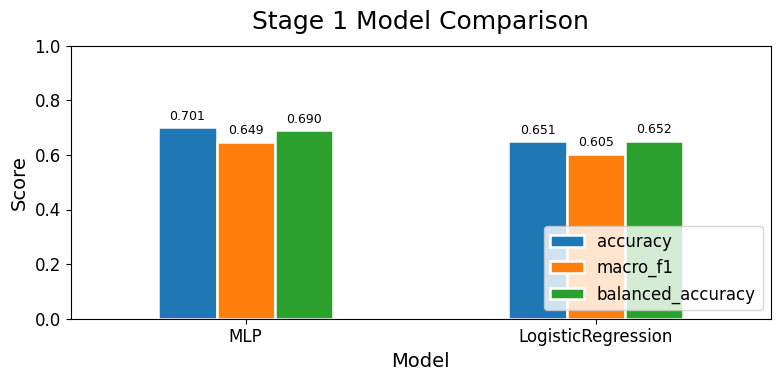

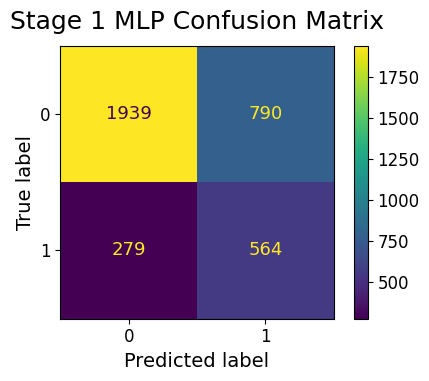

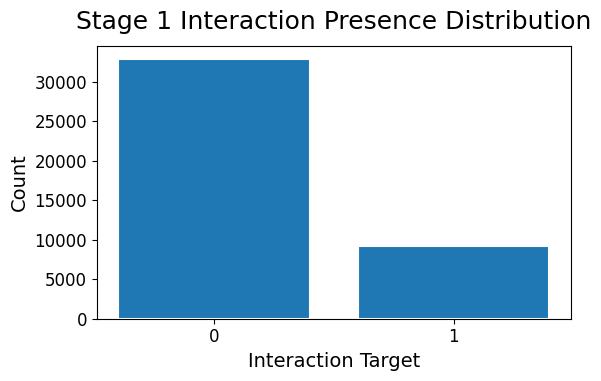

,target_verb,count,ratio
0,decontact,3603,0.392484
1,first_contact,3323,0.361983
2,release,1200,0.130719
3,take,1054,0.114815


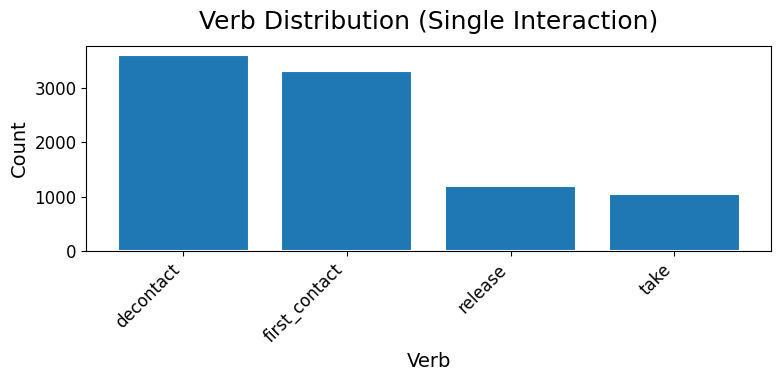

,target_object,count,ratio
0,oscilloscope,2529,0.275490
1,low_voltage_board,848,0.092375
2,power_supply_cables,701,0.076362
3,power_supply,630,0.068627
4,high_voltage_board,578,0.062963
5,socket_1,566,0.061656
6,oscilloscope_probe_tip,496,0.054031
7,welder_station,383,0.041721
8,socket_2,374,0.040741
9,socket_3,366,0.039869


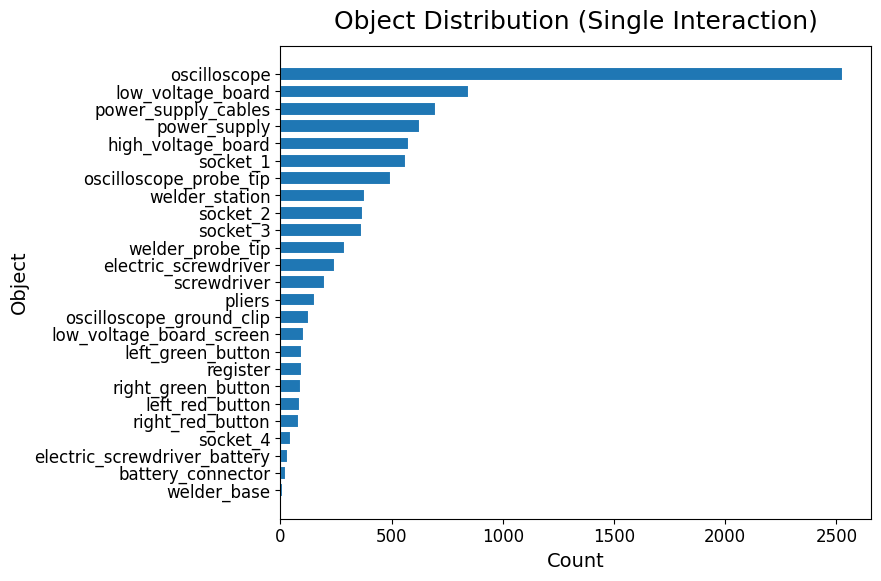

,target_pair,count,ratio
0,decontact__oscilloscope,1315,0.143246
1,first_contact__oscilloscope,1209,0.131699
2,decontact__low_voltage_board,367,0.039978
3,decontact__power_supply,322,0.035076
4,first_contact__power_supply,306,0.033333
5,decontact__socket_1,295,0.032135
6,first_contact__low_voltage_board,290,0.031590
7,release__power_supply_cables,279,0.030392
8,release__oscilloscope_probe_tip,274,0.029847
9,first_contact__socket_1,271,0.029521


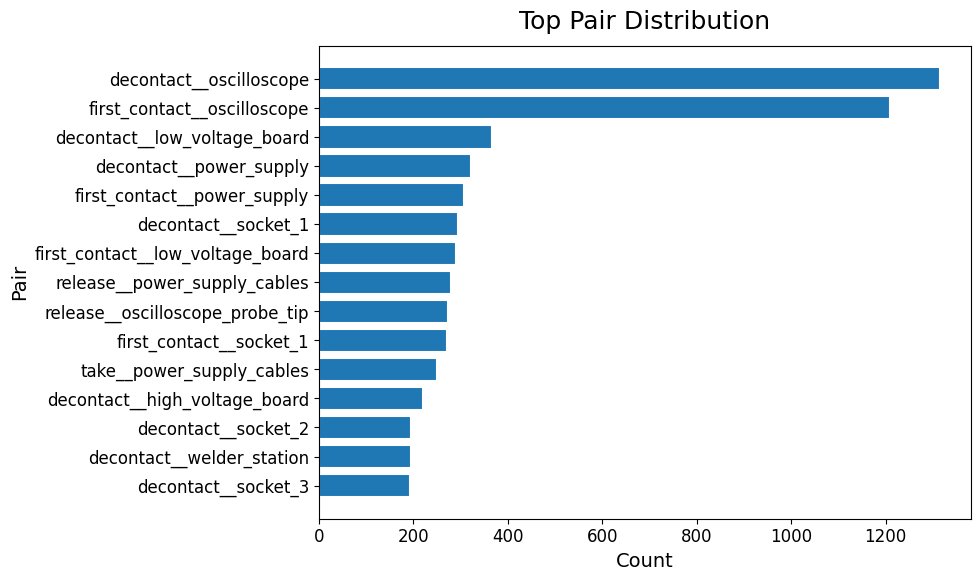

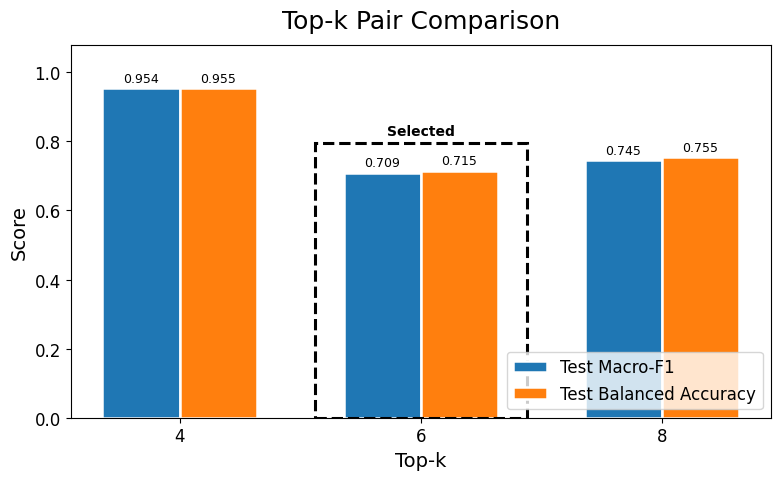

,part,final_model,test_accuracy,test_macro_f1,test_balanced_accuracy
0,Interaction Presence,LSTM,0.743885,0.665723,0.677325
1,Current Pair,GRU*,0.906040,0.812077,0.851965
2,Future Pair,LSTM,0.709898,0.520255,0.570439


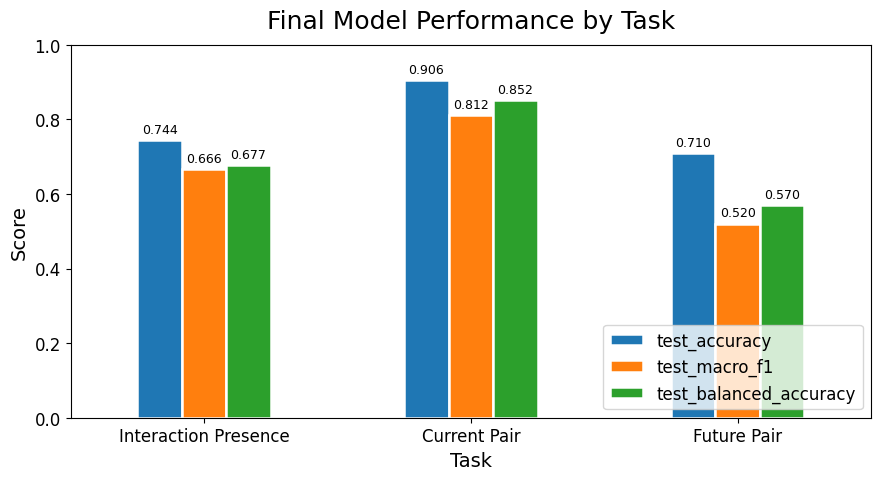

All figures were saved to: /content/enigma_outputs/figures


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib.patches import Rectangle

# =========================
# 경로 설정
# =========================
CSV_DIR = Path("/content/enigma_outputs/csv")
FIG_DIR = Path("/content/enigma_outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 폰트/크기 전역 설정
# =========================
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams["font.size"] = 13
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["figure.titlesize"] = 18

# =========================
# 저장 함수
# =========================
def save_current_fig(filename):
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

# =========================
# 1. Stage 1 모델 비교
# =========================
stage1_compare_df = pd.read_csv(CSV_DIR / "interaction_single_frame_compare.csv")
display(stage1_compare_df)

ax = stage1_compare_df.set_index("model")[["accuracy", "macro_f1", "balanced_accuracy"]].plot(
    kind="bar",
    figsize=(8, 4),
    edgecolor="white",
    linewidth=1.8
)
plt.title("Stage 1 Model Comparison", pad=12)
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.legend(loc="lower right")
save_current_fig("stage1_model_comparison.png")


# =========================
# 2. Stage 1 Confusion Matrix
# =========================
cm = interaction_mlp_result["confusion_matrix"]

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(ax=ax, values_format="d")
plt.title("Stage 1 MLP Confusion Matrix", pad=12)
save_current_fig("stage1_mlp_confusion_matrix.png")


# =========================
# 3. Interaction Presence Distribution
# =========================
interaction_df = pd.read_csv(CSV_DIR / "interaction_presence_frames.csv")
interaction_counts = interaction_df["interaction_target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(interaction_counts.index.astype(str), interaction_counts.values,
        edgecolor="white", linewidth=1.5)
plt.title("Stage 1 Interaction Presence Distribution", pad=12)
plt.xlabel("Interaction Target")
plt.ylabel("Count")
save_current_fig("interaction_presence_distribution.png")


# =========================
# 4. Verb Distribution
# =========================
verb_df = pd.read_csv(CSV_DIR / "dist_top_verbs_single_interaction.csv")
display(verb_df)

verb_col = verb_df.columns[0]
count_col = verb_df.columns[1]

plt.figure(figsize=(8, 4))
plt.bar(verb_df[verb_col], verb_df[count_col],
        edgecolor="white", linewidth=1.5)
plt.title("Verb Distribution (Single Interaction)", pad=12)
plt.xlabel("Verb")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
save_current_fig("verb_distribution_single_interaction.png")


# =========================
# 5. Object Distribution
# =========================
obj_df = pd.read_csv(CSV_DIR / "dist_top_objects_single_interaction.csv")
display(obj_df)

obj_col = obj_df.columns[0]
count_col = obj_df.columns[1]

plt.figure(figsize=(9, 6))
plt.barh(obj_df[obj_col], obj_df[count_col],
         edgecolor="white", linewidth=1.5)
plt.gca().invert_yaxis()
plt.title("Object Distribution (Single Interaction)", pad=12)
plt.xlabel("Count")
plt.ylabel("Object")
save_current_fig("object_distribution_single_interaction.png")


# =========================
# 6. Pair Distribution
# =========================
pair_dist_df = pd.read_csv(CSV_DIR / "dist_top_pairs_single_interaction.csv").head(15)
display(pair_dist_df)

pair_col = pair_dist_df.columns[0]
count_col = pair_dist_df.columns[1]

plt.figure(figsize=(10, 6))
plt.barh(pair_dist_df[pair_col], pair_dist_df[count_col],
         edgecolor="white", linewidth=1.5)
plt.gca().invert_yaxis()
plt.title("Top Pair Distribution", pad=12)
plt.xlabel("Count")
plt.ylabel("Pair")
save_current_fig("top_pair_distribution.png")


# =========================
# 7. Top-k Pair Comparison
# =========================
topk_df = pd.read_csv(CSV_DIR / "pair_topk_compare_train_based.csv")

plot_df = topk_df[["top_k", "test_macro_f1", "test_balanced_accuracy"]].copy()
plot_df = plot_df.sort_values("top_k").reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(
    x - width/2,
    plot_df["test_macro_f1"],
    width=width,
    label="Test Macro-F1",
    edgecolor="white",
    linewidth=1.8
)

bars2 = ax.bar(
    x + width/2,
    plot_df["test_balanced_accuracy"],
    width=width,
    label="Test Balanced Accuracy",
    edgecolor="white",
    linewidth=1.8
)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.01,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

selected_idx = plot_df.index[plot_df["top_k"] == 6][0]
left = x[selected_idx] - width - 0.12
rect_width = 2 * width + 0.24
rect_height = max(
    plot_df.loc[selected_idx, "test_macro_f1"],
    plot_df.loc[selected_idx, "test_balanced_accuracy"]
) + 0.08

highlight = Rectangle(
    (left, 0),
    rect_width,
    rect_height,
    fill=False,
    edgecolor="black",
    linewidth=2.2,
    linestyle="--"
)
ax.add_patch(highlight)

ax.text(
    x[selected_idx],
    rect_height + 0.015,
    "Selected",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold"
)

ax.set_title("Top-k Pair Comparison", pad=12)
ax.set_xlabel("Top-k")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["top_k"].astype(str))
ax.set_ylim(0, 1.08)
ax.legend(loc="lower right")

save_current_fig("topk_pair_comparison.png")


# =========================
# 8. Final Model Performance
# =========================
final_model_df = pd.DataFrame([
    {
        "part": "Interaction Presence",
        "final_model": "LSTM",
        "test_accuracy": 0.743885,
        "test_macro_f1": 0.665723,
        "test_balanced_accuracy": 0.677325,
    },
    {
        "part": "Current Pair",
        "final_model": "GRU*",
        "test_accuracy": 0.906040,
        "test_macro_f1": 0.812077,
        "test_balanced_accuracy": 0.851965,
    },
    {
        "part": "Future Pair",
        "final_model": "LSTM",
        "test_accuracy": 0.709898,
        "test_macro_f1": 0.520255,
        "test_balanced_accuracy": 0.570439,
    },
])

display(final_model_df)

plot_df = final_model_df.set_index("part")[[
    "test_accuracy", "test_macro_f1", "test_balanced_accuracy"
]]

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5),
    edgecolor="white",
    linewidth=1.8
)

plt.title("Final Model Performance by Task", pad=12)
plt.xlabel("Task")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.legend(loc="lower right")
save_current_fig("final_model_performance_by_task.png")


print(f"All figures were saved to: {FIG_DIR}")

In [ ]:
import json
import joblib
import torch
from pathlib import Path

ARTIFACT_DIR = Path("/content/enigma_outputs/artifacts")
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
interaction_dir = ARTIFACT_DIR / "interaction"

with open(interaction_dir / "config.json", "r", encoding="utf-8") as f:
    interaction_config = json.load(f)

with open(interaction_dir / "label_info.json", "r", encoding="utf-8") as f:
    interaction_label_info = json.load(f)

interaction_scaler = joblib.load(interaction_dir / "scaler.pkl")

interaction_model = SequenceClassifier(
    input_dim=interaction_config["input_dim"],
    num_classes=interaction_config["num_classes"],
    model_type="LSTM",   # config["model"]이 LSTM이니까
    hidden_size=interaction_config["hidden_size"],
    num_layers=1,
    dropout=interaction_config["dropout"],
    bidirectional=False
).to(device)

interaction_model.load_state_dict(
    torch.load(interaction_dir / "model.pt", map_location=device)
)
interaction_model.eval()

print("interaction model loaded")

interaction model loaded


In [ ]:
current_dir = ARTIFACT_DIR / "current_pair"

with open(current_dir / "config.json", "r", encoding="utf-8") as f:
    current_config = json.load(f)

with open(current_dir / "label_info.json", "r", encoding="utf-8") as f:
    current_label_info = json.load(f)

current_scaler = joblib.load(current_dir / "scaler.pkl")

current_model_name = current_config["model"]
current_bidirectional = True if current_model_name == "BiLSTM" else False
current_model_type = "LSTM" if current_model_name == "BiLSTM" else current_model_name

current_pair_model = SequenceClassifier(
    input_dim=current_config["input_dim"],
    num_classes=current_config["num_classes"],
    model_type=current_model_type,
    hidden_size=current_config["hidden_size"],
    num_layers=1,
    dropout=current_config["dropout"],
    bidirectional=current_bidirectional
).to(device)

current_pair_model.load_state_dict(
    torch.load(current_dir / "model.pt", map_location=device)
)
current_pair_model.eval()

print("current pair model loaded")

current pair model loaded


In [ ]:
test_ds = SequenceDataset(
    current_data["X_test"],
    current_data["y_test"]
)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

criterion = torch.nn.CrossEntropyLoss()

current_pair_test_metrics = evaluate_model(
    current_pair_model,
    test_loader,
    criterion,
    device
)

print(current_pair_test_metrics)

{'accuracy': 0.889261744966443, 'macro_f1': 0.7530931097953742, 'balanced_accuracy': np.float64(0.7630619339321282), 'loss': 0.3434422258412678}


In [ ]:
future_dir = ARTIFACT_DIR / "future_pair"

with open(future_dir / "config.json", "r", encoding="utf-8") as f:
    future_config = json.load(f)

with open(future_dir / "label_info.json", "r", encoding="utf-8") as f:
    future_label_info = json.load(f)

future_scaler = joblib.load(future_dir / "scaler.pkl")

future_model_name = future_config["model"]
future_bidirectional = True if future_model_name == "BiLSTM" else False
future_model_type = "LSTM" if future_model_name == "BiLSTM" else future_model_name

future_pair_model = SequenceClassifier(
    input_dim=future_config["input_dim"],
    num_classes=future_config["num_classes"],
    model_type=future_model_type,
    hidden_size=future_config["hidden_size"],
    num_layers=1,
    dropout=future_config["dropout"],
    bidirectional=future_bidirectional
).to(device)

future_pair_model.load_state_dict(
    torch.load(future_dir / "model.pt", map_location=device)
)
future_pair_model.eval()

print("future pair model loaded")

future pair model loaded


In [ ]:
test_ds = SequenceDataset(
    future_data["X_test"],
    future_data["y_test"]
)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

criterion = torch.nn.CrossEntropyLoss()

future_pair_test_metrics = evaluate_model(
    future_pair_model,
    test_loader,
    criterion,
    device
)

print(future_pair_test_metrics)

{'accuracy': 0.7303754266211604, 'macro_f1': 0.4756240345928622, 'balanced_accuracy': np.float64(0.4856804923981443), 'loss': 0.7982830077714888}


In [ ]:
x_sample = current_data["X_test"][0:1]
x_tensor = torch.tensor(x_sample, dtype=torch.float32).to(device)

with torch.no_grad():
    logits = current_pair_model(x_tensor)
    pred_idx = torch.argmax(logits, dim=1).item()

print("pred idx:", pred_idx)
print("pred label:", current_label_info["idx_to_label"][str(pred_idx)])
print("true label idx:", current_data["y_test"][0])

pred idx: 5
pred label: first_contact__power_supply
true label idx: 5


In [ ]:
import torch

idx_to_label = current_label_info["idx_to_label"]

for i in range(10):
    x_sample = current_data["X_test"][i:i+1]
    x_tensor = torch.tensor(x_sample, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = current_pair_model(x_tensor)
        pred_idx = torch.argmax(logits, dim=1).item()

    true_idx = int(current_data["y_test"][i])

    print(f"[sample {i}]")
    print("pred idx   :", pred_idx)
    print("pred label :", idx_to_label[str(pred_idx)])
    print("true idx   :", true_idx)
    print("true label :", idx_to_label[str(true_idx)])
    print("-" * 50)

[sample 0]
pred idx   : 5
pred label : first_contact__power_supply
true idx   : 5
true label : first_contact__power_supply
--------------------------------------------------
[sample 1]
pred idx   : 2
pred label : decontact__low_voltage_board
true idx   : 2
true label : decontact__low_voltage_board
--------------------------------------------------
[sample 2]
pred idx   : 0
pred label : decontact__oscilloscope
true idx   : 3
true label : decontact__power_supply
--------------------------------------------------
[sample 3]
pred idx   : 0
pred label : decontact__oscilloscope
true idx   : 0
true label : decontact__oscilloscope
--------------------------------------------------
[sample 4]
pred idx   : 0
pred label : decontact__oscilloscope
true idx   : 3
true label : decontact__power_supply
--------------------------------------------------
[sample 5]
pred idx   : 5
pred label : first_contact__power_supply
true idx   : 5
true label : first_contact__power_supply
-----------------------------

In [ ]:
correct = 0
n = 20

for i in range(n):
    x_sample = current_data["X_test"][i:i+1]
    x_tensor = torch.tensor(x_sample, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = current_pair_model(x_tensor)
        pred_idx = torch.argmax(logits, dim=1).item()

    true_idx = int(current_data["y_test"][i])

    if pred_idx == true_idx:
        correct += 1

print(f"first {n} samples correct: {correct}/{n}")

first 20 samples correct: 18/20


In [ ]:
from torch.utils.data import DataLoader

test_ds = SequenceDataset(
    interaction_current_data["X_test"],
    interaction_current_data["y_test"]
)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

criterion = torch.nn.CrossEntropyLoss()

interaction_test_metrics = evaluate_model(
    interaction_model,
    test_loader,
    criterion,
    device
)

print(interaction_test_metrics)

{'accuracy': 0.743885296598257, 'macro_f1': 0.6657233880989893, 'balanced_accuracy': np.float64(0.6773250871935083), 'loss': 0.622917763647954}


In [ ]:
# 모델 저장

import shutil
from pathlib import Path

ARTIFACT_DIR = Path("/content/enigma_outputs/artifacts")
zip_base = "/content/enigma_outputs/enigma_artifacts"

shutil.make_archive(zip_base, "zip", ARTIFACT_DIR)

print("saved:", zip_base + ".zip")

saved: /content/enigma_outputs/enigma_artifacts.zip


In [ ]:
!pip install -q streamlit joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 28.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

cm = np.array(interaction_mlp_result["confusion_matrix"])

correct = cm[0, 0] + cm[1, 1]
incorrect = cm[0, 1] + cm[1, 0]

agree_df = pd.DataFrame({
    "status": ["Correct", "Incorrect"],
    "count": [correct, incorrect]
})

ax = agree_df.plot(
    kind="bar",
    x="status",
    y="count",
    figsize=(6, 4),
    legend=False,
    edgecolor="white",
    linewidth=1.8
)

plt.title("Stage 1 Prediction Agreement", pad=12)
plt.xlabel("")
plt.ylabel("Count")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=10)

save_current_fig("stage1_prediction_agreement.png")

In [ ]:
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
up to date, audited 23 packages in 2s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸
2 vulnerabilities (1 high, 1 critical)

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠸

In [ ]:
!streamlit run app.py --server.port 8501 &>/content/streamlit.log &

In [ ]:
import json
import joblib
import numpy as np
import pandas as pd
import streamlit as st
import torch
import torch.nn as nn
from pathlib import Path

# =========================
# paths
# =========================
OUTPUT_ROOT = Path("/content/enigma_outputs")
ARTIFACT_DIR = OUTPUT_ROOT / "artifacts"
CSV_DIR = OUTPUT_ROOT / "csv"

FRAMES_DIR = Path("/content/enigma_data/frames")
FEATURE_DIR = Path("/content/enigma_data/features")

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# model
# =========================
class SequenceClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        num_classes,
        model_type="LSTM",
        hidden_size=128,
        num_layers=1,
        dropout=0.3,
        bidirectional=False
    ):
        super().__init__()
        self.model_type = model_type
        self.bidirectional = bidirectional

        rnn_cls = {"GRU": nn.GRU, "LSTM": nn.LSTM}[model_type]
        self.encoder = rnn_cls(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        out_dim = hidden_size * (2 if bidirectional else 1)
        self.head = nn.Linear(out_dim, num_classes)

    def forward(self, x):
        out, hidden = self.encoder(x)
        if self.model_type == "LSTM":
            hidden = hidden[0]  # h_n only

        if self.bidirectional:
            feat = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            feat = hidden[-1]

        return self.head(feat)

# =========================
# utils
# =========================
def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def build_model_from_config(config: dict):
    model_name = config["model"]

    if model_name == "BiLSTM":
        model_type = "LSTM"
        bidirectional = True
    elif model_name == "LSTM":
        model_type = "LSTM"
        bidirectional = False
    elif model_name == "GRU":
        model_type = "GRU"
        bidirectional = False
    else:
        raise ValueError(f"Unsupported model: {model_name}")

    model = SequenceClassifier(
        input_dim=config["input_dim"],
        num_classes=config["num_classes"],
        model_type=model_type,
        hidden_size=config["hidden_size"],
        num_layers=1,
        dropout=config["dropout"],
        bidirectional=bidirectional
    )
    return model

@st.cache_resource
def load_artifact_bundle(task_dir_name: str):
    task_dir = ARTIFACT_DIR / task_dir_name

    config = load_json(task_dir / "config.json")
    label_info = load_json(task_dir / "label_info.json")
    scaler = joblib.load(task_dir / "scaler.pkl")

    model = build_model_from_config(config)
    model.load_state_dict(torch.load(task_dir / "model.pt", map_location=device))
    model.to(device)
    model.eval()

    return model, scaler, label_info, config

def transform_sequence_array(X_seq: np.ndarray, scaler):
    # X_seq: [B, T, D]
    B, T, D = X_seq.shape
    X2 = X_seq.reshape(B * T, D)
    X2 = scaler.transform(X2)
    return X2.reshape(B, T, D)

def predict_one_sequence(model, scaler, label_info, seq_np: np.ndarray):
    seq_np = transform_sequence_array(seq_np, scaler)
    x = torch.tensor(seq_np, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))

    idx_to_label = label_info.get("idx_to_label", {})
    pred_label = idx_to_label.get(str(pred_idx), str(pred_idx))

    return pred_idx, pred_label, probs

def find_feature_path(frame_key: str):
    p = FEATURE_DIR / f"{frame_key}.npy"
    return p if p.exists() else None

def load_feature(frame_key: str):
    p = find_feature_path(frame_key)
    if p is None:
        return None
    return np.load(p)

def make_seq_from_frame_keys(frame_keys):
    feats = []
    for fk in frame_keys:
        arr = load_feature(fk)
        if arr is None:
            return None
        feats.append(arr)
    # [1, T, D]
    return np.stack(feats, axis=0)[None, ...]

def find_frame_image(frame_key: str):
    candidates = [
        FRAMES_DIR / f"{frame_key}.jpg",
        FRAMES_DIR / f"{frame_key}.png",
        FRAMES_DIR / f"{frame_key}.jpeg",
    ]
    for p in candidates:
        if p.exists():
            return p
    return None

def format_prob_table(probs, label_info):
    idx_to_label = label_info.get("idx_to_label", {})
    rows = []
    for i, p in enumerate(probs):
        rows.append({
            "class_idx": i,
            "label": idx_to_label.get(str(i), str(i)),
            "probability": float(p)
        })
    df = pd.DataFrame(rows).sort_values("probability", ascending=False).reset_index(drop=True)
    return df

# =========================
# data
# =========================
@st.cache_data
def load_frames_df():
    df = pd.read_csv(CSV_DIR / "eda_frames.csv")
    return df

@st.cache_data
def load_single_df():
    df = pd.read_csv(CSV_DIR / "single_interaction_frames.csv")
    return df

# =========================
# app
# =========================
st.set_page_config(page_title="ENIGMA Interaction Demo", layout="wide")

st.title("산업 작업 상호작용 분류 데모")
st.caption("최근 4개 프레임을 기준으로 상호작용 유무 → 현재 pair → 미래 pair를 예측합니다.")

frames_df = load_frames_df()
single_df = load_single_df()

# sidebar
st.sidebar.header("입력 선택")

video_ids = sorted(frames_df["video_id"].astype(str).unique().tolist())
selected_video = st.sidebar.selectbox("비디오 선택", video_ids)

video_df = frames_df[frames_df["video_id"].astype(str) == selected_video].copy()
video_df = video_df.sort_values("timestamp").reset_index(drop=True)

if len(video_df) < 4:
    st.error("선택한 비디오의 프레임 수가 4개 미만입니다.")
    st.stop()

selected_end_idx = st.sidebar.slider(
    "현재 프레임 위치 선택",
    min_value=3,
    max_value=len(video_df) - 1,
    value=min(10, len(video_df) - 1),
    step=1
)

seq_len = 4
seq_df = video_df.iloc[selected_end_idx - seq_len + 1:selected_end_idx + 1].copy()
seq_frame_keys = seq_df["frame_key"].tolist()

st.sidebar.markdown("### 선택된 4개 frame_key")
for fk in seq_frame_keys:
    st.sidebar.write(fk)

run_btn = st.sidebar.button("예측 실행", use_container_width=True)

# main info
col_left, col_right = st.columns([1.1, 1.2])

with col_left:
    st.subheader("선택 정보")
    st.write("video_id:", selected_video)
    st.dataframe(seq_df[["frame_key", "timestamp", "num_interactions"]], use_container_width=True)

with col_right:
    st.subheader("선택된 프레임")
    img_cols = st.columns(seq_len)

    for col, fk in zip(img_cols, seq_frame_keys):
        img_path = find_frame_image(fk)
        with col:
            st.caption(fk)
            if img_path is not None:
                st.image(str(img_path), use_container_width=True)
            else:
                st.warning("이미지 없음")

if run_btn:
    seq_np = make_seq_from_frame_keys(seq_frame_keys)

    if seq_np is None:
        st.error("선택한 frame_key 중 일부에 대응하는 npy feature를 찾지 못했습니다.")
        st.stop()

    # artifacts
    interaction_model, interaction_scaler, interaction_label_info, interaction_config = load_artifact_bundle("interaction")
    current_model, current_scaler, current_label_info, current_config = load_artifact_bundle("current_pair")
    future_model, future_scaler, future_label_info, future_config = load_artifact_bundle("future_pair")

    st.markdown("---")
    st.subheader("예측 결과")

    # interaction prediction
    inter_idx, inter_label, inter_probs = predict_one_sequence(
        interaction_model,
        interaction_scaler,
        interaction_label_info,
        seq_np
    )

    r1, r2 = st.columns([0.9, 1.1])

    with r1:
        st.markdown("### 1) 상호작용 유무")
        st.success(f"예측 결과: **{inter_label}**")

    with r2:
        st.markdown("### 상호작용 유무 확률")
        inter_prob_df = format_prob_table(inter_probs, interaction_label_info)
        st.dataframe(inter_prob_df, use_container_width=True)

    if inter_idx == 1:
        # current pair
        cur_idx, cur_label, cur_probs = predict_one_sequence(
            current_model,
            current_scaler,
            current_label_info,
            seq_np
        )

        # future pair
        fut_idx, fut_label, fut_probs = predict_one_sequence(
            future_model,
            future_scaler,
            future_label_info,
            seq_np
        )

        st.markdown("---")
        c1, c2 = st.columns(2)

        with c1:
            st.markdown("### 2) 현재 pair 분류")
            st.success(f"예측 pair: **{cur_label}**")
            cur_prob_df = format_prob_table(cur_probs, current_label_info)
            st.dataframe(cur_prob_df, use_container_width=True)

        with c2:
            st.markdown("### 3) 미래 pair 분류")
            st.info(f"다음 시점 예측 pair: **{fut_label}**")
            fut_prob_df = format_prob_table(fut_probs, future_label_info)
            st.dataframe(fut_prob_df, use_container_width=True)
    else:
        st.info("상호작용 없음으로 판정되어 pair 분류는 생략했습니다.")

2026-04-09 21:59:28.956 No runtime found, using MemoryCacheStorageManager
2026-04-09 21:59:28.959 No runtime found, using MemoryCacheStorageManager
2026-04-09 21:59:28.967 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 21:59:28.974 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 21:59:28.976 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 21:59:28.980 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 21:59:28.984 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 21:59:28.985 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 21:59:28.987 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor